# Part 1: Data Exploration and Cleaning

## Task 1.1: Initial Data Assessment

Loading Dataset and Perfoming Initial Exploration

Subtasks:
1. Display basic dataset information (shape, data types, memory usage)
2. Identify and document any missing values
3. Check for duplicate records
4. Examine the range and distribution of numerical variables
5. Explore the unique values in categorical columns

In [ ]:
## Importing Necessary Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading File From Computer
from google.colab import files
file_uploaded = files.upload()

Saving Coffee Shop Sales.xlsx to Coffee Shop Sales.xlsx


In [ ]:
# Loading Dataset to DataFrame
sales_df = pd.read_excel(list(file_uploaded.keys())[0])

### Displaying basic dataset information (shape, data types, memory usage)

In [ ]:
#Dataset Shape
sales_df.shape

(149116, 11)

In [ ]:
## Data types And Memory Usage
sales_df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 48.8 MB


### Identifying Missing Values:
To identify missing values, We have used the `.isnull()` method to create a boolean DataFrame indicating missing values and then `.sum()` to count them for each column in `sales_df`.



In [ ]:
## Using isnull
missing_values = sales_df.isnull().sum()
print("Missing values per column:\n")
missing_values

Missing values per column:



,0
transaction_id,0
transaction_date,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


In [ ]:
## Using isna
missing_values = sales_df.isna().sum()
print("Missing values per column:\n")
missing_values

Missing values per column:



,0
transaction_id,0
transaction_date,0
transaction_time,0
transaction_qty,0
store_id,0
store_location,0
product_id,0
unit_price,0
product_category,0
product_type,0


#### **Observation**
##### No Missing Values Observed

### Checking for Duplicate Records

To Check for the duplicate rows, We Have used the `.duplicated()` method to identify duplicates and then `.sum()` to get the total count.


In [ ]:
duplicate_rows = sales_df.duplicated().sum()
print(f"Total number of duplicate rows: {duplicate_rows}")

Total number of duplicate rows: 0


#### Checking For duplicated values excluding Transaction ID Column
Same Transaction Recorded Several Times?Retries?Timeouts?

In [ ]:
sales_df.duplicated(subset=sales_df.columns.difference(['transaction_id'])).sum()

np.int64(398)

#### **Observation**:
When We Analyse a row to check for duplicates excluding TransactionID Column, `398` rows have duplicate Values

### Examining the Range and Distribution of Numerical Variables

In order to understand the distribution and summary statistics of numerical columns, we Have Used the `.describe()`.

In [ ]:
sales_df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


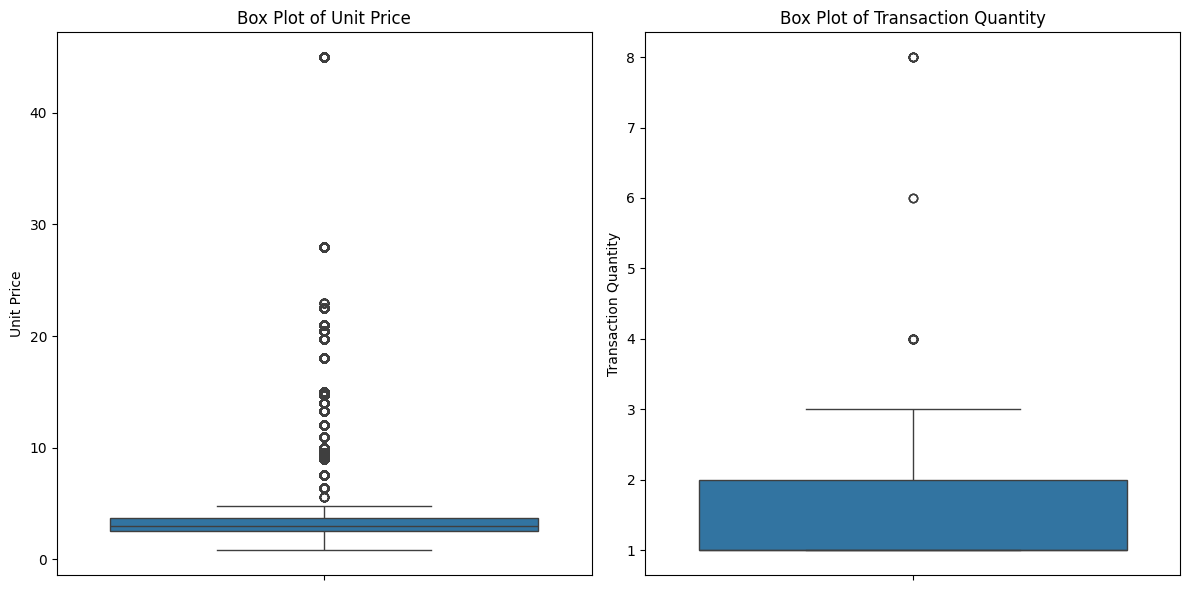

In [ ]:
## Using Box Plot To Check Data Distribution And Any Outlier!


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=sales_df['unit_price'])
plt.title('Box Plot of Unit Price')
plt.ylabel('Unit Price')

plt.subplot(1, 2, 2)
sns.boxplot(y=sales_df['transaction_qty'])
plt.title('Box Plot of Transaction Quantity')
plt.ylabel('Transaction Quantity')

plt.tight_layout()
plt.show()

What this tells us:

for `unit_price`
- Most products are low-priced.
- There is a small group of much more expensive items.

for `transacation_qty`
- Amost all of rows are of quantity 1 to 3


### Exploring the Unique Values in Categorical Columns

In [ ]:
sales_df.describe(include='object')

,transaction_time,store_location,product_category,product_type,product_detail
count,149116,149116,149116,149116,149116
unique,25762,3,9,29,80
top,09:31:15,Hell's Kitchen,Coffee,Brewed Chai tea,Chocolate Croissant
freq,41,50735,58416,17183,3076


In [ ]:
# Define the categorical columns so that we Analyze by Store.

cat_cols = ['transaction_time', 'product_category', 'product_type', 'product_detail']
# Note: 'store_location' itself is not included since we're grouping by it

# Group by store and get describe() for each categorical column
for store in sorted(sales_df['store_location'].unique()):
    print(f"Store: {store}")

    subset = sales_df[sales_df['store_location'] == store]

    # Show summary for each categorical column
    summary = subset[cat_cols].describe(include='object')
    print(summary)

    # Optional: also show number of transactions in this store
    print(f"\nTotal transactions: {len(subset):,}")

Store: Astoria
       transaction_time product_category     product_type     product_detail
count             50599            50599            50599              50599
unique            11043                9               29                 79
top            10:34:04           Coffee  Brewed Chai tea  Dark chocolate Lg
freq                 35            20025             6293               1166

Total transactions: 50,599
Store: Hell's Kitchen
       transaction_time product_category      product_type  \
count             50735            50735             50735   
unique            11567                9                29   
top            09:44:57           Coffee  Barista Espresso   
freq                 32            20187              6153   

              product_detail  
count                  50735  
unique                    80  
top     Ouro Brasileiro shot  
freq                    1363  

Total transactions: 50,735
Store: Lower Manhattan
       transaction_time product_c

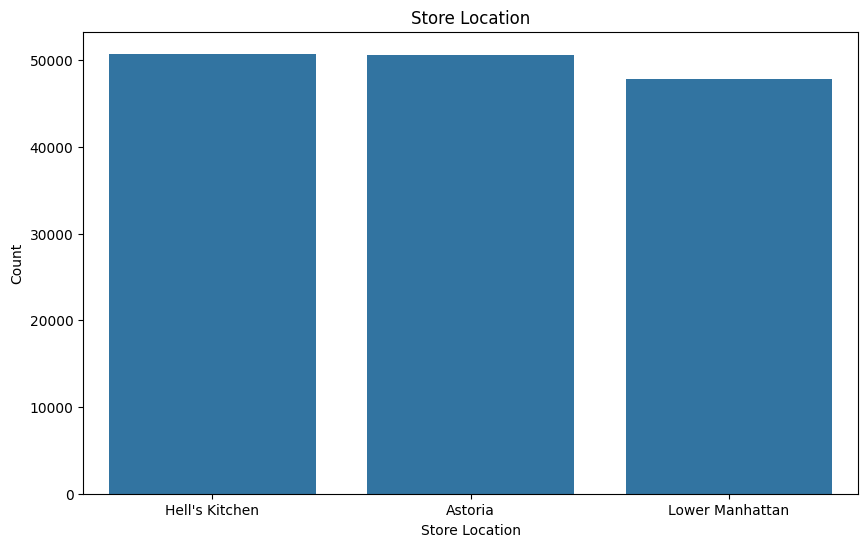

In [ ]:
## Visualising Distribution of Values in Categorical Columns

x,y = sales_df['store_location'].value_counts().index, sales_df['store_location'].value_counts().values
plt.figure(figsize=(10,6))
plt.title('Store Location')
plt.ylabel('Count')
plt.xlabel('Store Location')
sns.barplot(x=x, y=y)
plt.show()

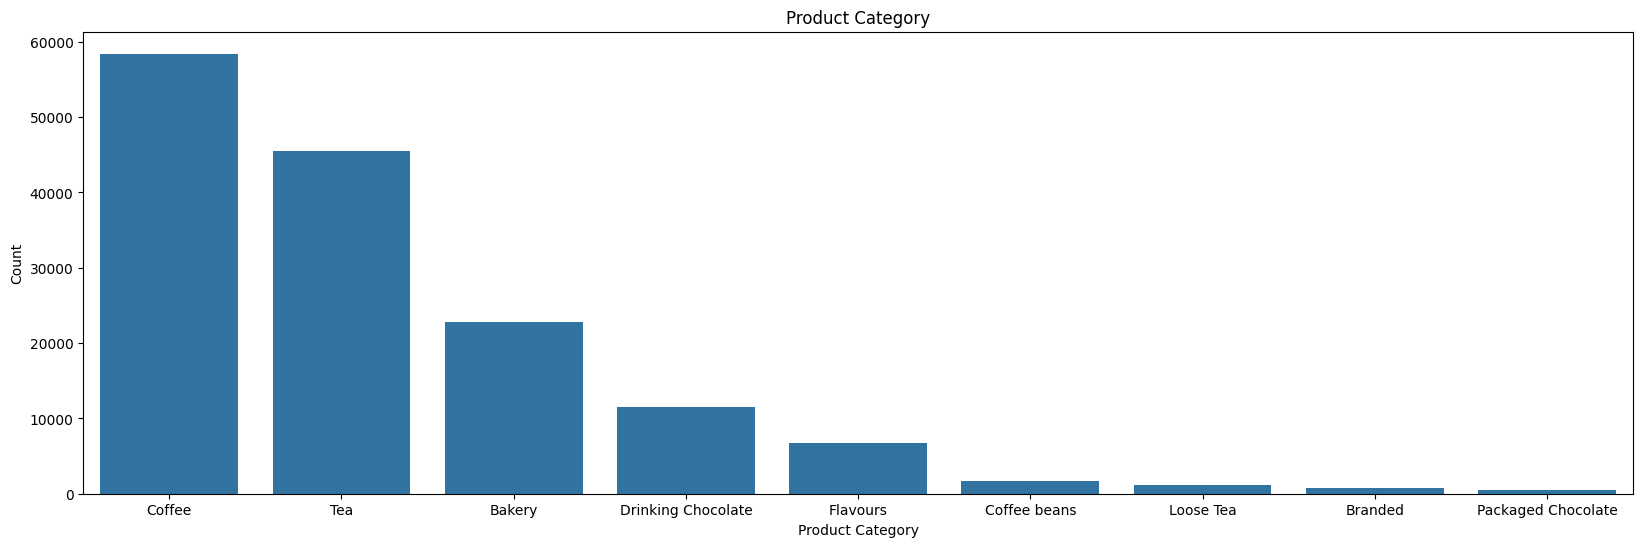

In [ ]:
x,y = sales_df['product_category'].value_counts().index, sales_df['product_category'].value_counts().values
plt.figure(figsize=(20,6))
plt.title('Product Category')
plt.ylabel('Count')
plt.xlabel('Product Category')
sns.barplot(x=x, y=y)
plt.show()

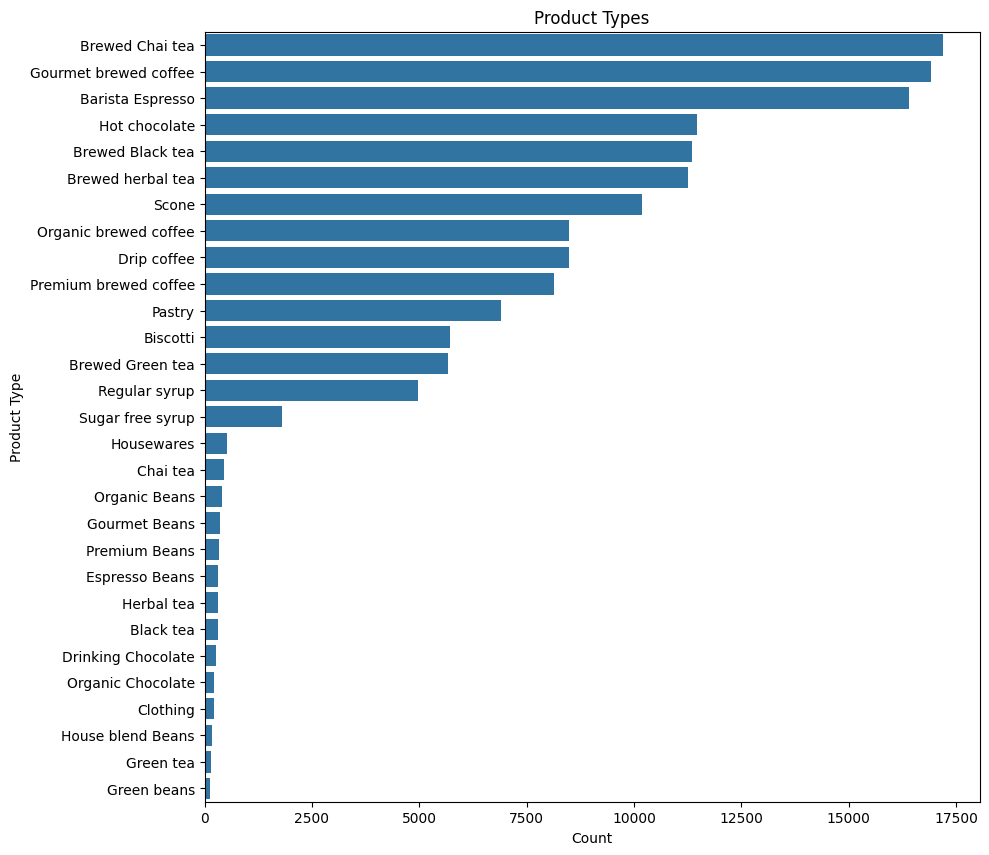

In [ ]:
plt.figure(figsize=(10,10))
plt.title('Product Types')
plt.ylabel('Product Type')
plt.xlabel('Count')
product_type = sales_df['product_type']
sns.countplot(product_type,order=product_type.value_counts().index)
plt.show()

### Summary:

Data Analysis Key Findings 1.1

*   **Missing Values**: No missing values were found in any of the columns (`transaction_id`, `transaction_date`, `transaction_time`, `transaction_qty`, `store_id`, `store_location`, `product_id`, `unit_price`, `product_category`, `product_type`, `product_detail`).

*   **Duplicate Records**: There are no duplicate rows in the dataset, indicating all records are unique.
    *   ***When We Exclude `Transaction_id` There are about `398` repeating Values***
*   **Numerical Column Statistics**:
    *   `transaction_qty` (transaction quantity) ranges from 1 to 8, with an average of approximately 1.44, suggesting most transactions involve 1 or 2 items.
    *   `unit_price` ranges from \$0.80 to \$45.00, with an average of \$3.38, indicating a variety of product pricing.
    *   `transaction_date` covers a period from 2023-01-01 to 2023-06-30.
*   **Categorical Column Unique Values**:
    *   `store_location` has three distinct values: "Hell's Kitchen" (50,735 transactions), "Astoria" (50,599 transactions), and "Lower Manhattan" (47,782 transactions), showing a relatively balanced distribution across locations.
    *   `product_category` includes 9 unique categories, with "Coffee" (58,416 transactions) and "Tea" (45,449 transactions) being the most frequent.
    *   `product_type` contains 29 unique types, with "Brewed Chai tea" (17,183 transactions), "Gourmet brewed coffee" (16,912 transactions), and "Barista Espresso" (16,403 transactions) as the top types.
    *   `product_detail` has 80 unique details, with "Chocolate Croissant" (3,076 transactions) and "Earl Grey Rg" (3,053 transactions) being among the most common.


### Critical Thinking Question 1.
After Initial Analysis We Have identified 3 Possible Data Quality Issues And Below is How We Have Planned and Address Them

To Do
*   To Investigate duplicate transactions,
*   To analyze `unit_price` outliers and distribution
*   To refine the `transaction_time` data type and Merge it with Date to Have one combined DateTime Column

#### Investigating Duplicate Transactions (excluding transaction_id)

To investigate the duplicate records, I will first identify and store all rows that are duplicates based on all columns except 'transaction_id'. Using `keep=False` will mark all occurrences of the duplicates, making it easier to examine them.



In [ ]:
duplicate_transactions = sales_df[sales_df.duplicated(subset=sales_df.columns.difference(['transaction_id']), keep=False)]
print(f"Number of rows with duplicate entries (excluding transaction_id): {len(duplicate_transactions)}")

Number of rows with duplicate entries (excluding transaction_id): 743


In [ ]:
duplicate_transactions.sort_values(by=['transaction_date','transaction_time']).head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
3255,3285,2023-01-07,07:00:50,1,5,Lower Manhattan,71,3.75,Bakery,Pastry,Chocolate Croissant
3256,3286,2023-01-07,07:00:50,1,5,Lower Manhattan,71,3.75,Bakery,Pastry,Chocolate Croissant
3437,3467,2023-01-07,09:31:48,1,8,Hell's Kitchen,71,3.75,Bakery,Pastry,Chocolate Croissant
3438,3468,2023-01-07,09:31:48,1,8,Hell's Kitchen,71,3.75,Bakery,Pastry,Chocolate Croissant
3507,3537,2023-01-07,10:29:12,1,5,Lower Manhattan,71,3.75,Bakery,Pastry,Chocolate Croissant


##### Analysis of Duplicate Transactions (excluding transaction_id)

We found **743 duplicate rows** when ignoring `transaction_id`. Looking at the first 20, the duplicates share the same details (time, product, quantity, store) but have different IDs. This suggests a few possibilities:

1. Multiple items from one purchase recorded as separate lines  
2. Near-simultaneous transactions  
3. Data entry or system error  
4. System retries

---

###### Implications

- **Sales Figures:** If duplicates are errors, they inflate transaction counts and product quantities.  
- **Product Popularity:** Items like *Chocolate Croissant* may look more popular than they really are.  
- **Customer Behavior:** Duplicates distort insights into peak times and buying patterns.

---

###### Plan for Handling Duplicates

1. **Check with Data Owner:** Confirm whether these are valid separate purchases or system artifacts.  
2. **If unclear:** Keep only the first occurrence of each unique combination (date, time, product, store, etc.).  
3. **Decision for now:** We Do not Have Enough Details to Conclude Whether or not these are Actual Duplicates


#### Investigating Unit price outliers and Distribution

In [ ]:
print("Descriptive statistics for 'unit_price':\n")
sales_df['unit_price'].describe()

Descriptive statistics for 'unit_price':



,unit_price
count,149116.000000
mean,3.382219
std,2.658723
min,0.800000
25%,2.500000
50%,3.000000
75%,3.750000
max,45.000000


To visualize the distribution of `unit_price` and identify potential outliers, We created a histogram and a box plot for the `unit_price` column.



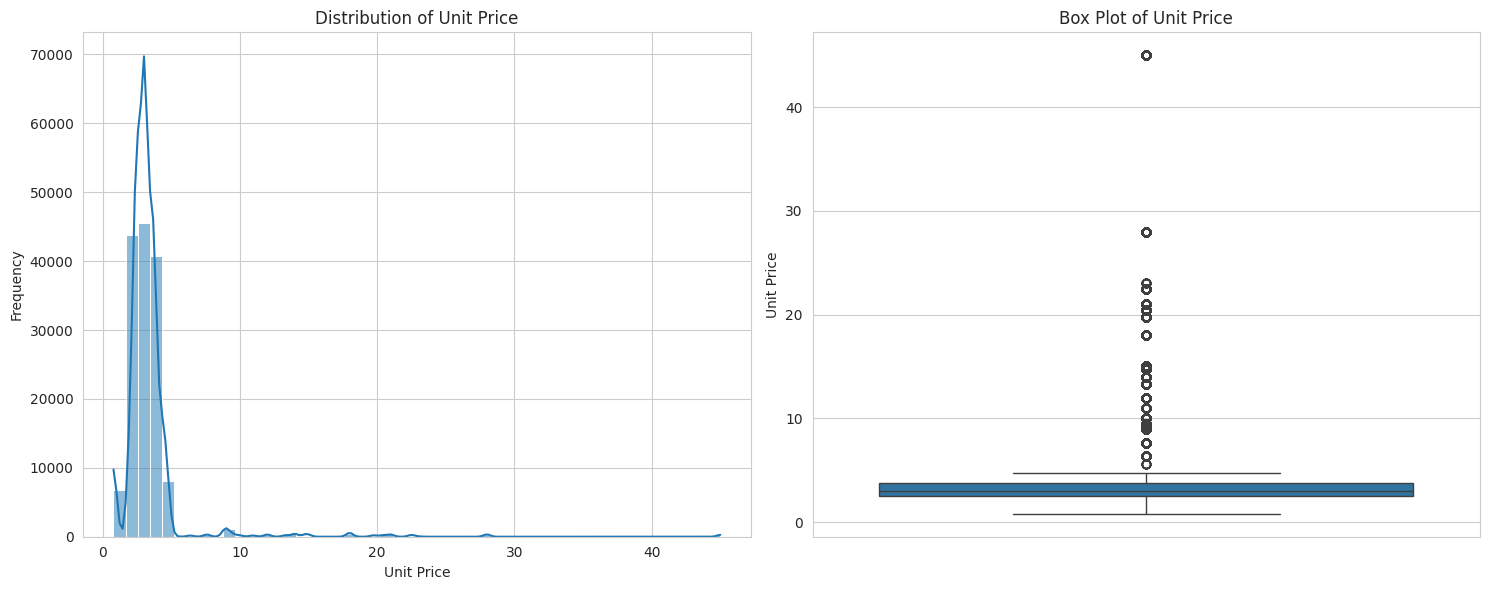

In [ ]:
plt.figure(figsize=(15, 6))
sns.set_style("whitegrid")
plt.subplot(1, 2, 1)
sns.histplot(sales_df['unit_price'], bins=50, kde=True)
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(y=sales_df['unit_price'])
plt.title('Box Plot of Unit Price')
plt.ylabel('Unit Price')

plt.tight_layout()
plt.show()

##### Analysis of `unit_price` Distribution and Outliers

The data shows most products are priced between **0–10**, with a heavy concentration below **5**. A few items are much higher, going up to **45**, which stand out as outliers.

---

###### Key Findings
- **Distribution:** Prices are right-skewed, with many low-cost items and fewer high-priced ones.  
- **Outliers:** The box plot highlights several high-value items well above the typical range.  
- **Stats Impact:** Outliers raise the mean ($3.38) above the median ($3.00), which is expected in skewed data.

---

###### Possible Reasons for Outliers
1. **Premium products** (specialty coffee, merchandise, larger packs).  
2. **Bundles or larger sizes** priced higher than single items.  
3. **Data entry errors**, though less likely for fixed prices.

---

###### Implications
- **Sales analysis:** Outliers can distort averages if not handled carefully.  

---

###### Plan
1. **Investigate high-priced items** by checking product details and categories.  
2. **Keep legitimate premium products** in the dataset if Any.  
3. **Correct/remove errors** if any are found.  
4. **For now:** No removal — we’ll note their presence and handle them cautiously in future Analysis.

---

###### Conclusion
Most products are low-cost, but a handful of premium or bundled items drive the outliers. These are likely valid business data, not errors, so they should remain in the dataset while being flagged for careful treatment in analysis.


#### Refining the `transaction_time` data type.

In [ ]:
print(f"Current data type of 'transaction_time': {sales_df['transaction_time'].dtype}")
print("Sample unique values from 'transaction_time':")
print(sales_df['transaction_time'].unique()[:5])

Current data type of 'transaction_time': object
Sample unique values from 'transaction_time':
[datetime.time(7, 6, 11) datetime.time(7, 8, 56) datetime.time(7, 14, 4)
 datetime.time(7, 20, 24) datetime.time(7, 22, 41)]


**WHY**:

To ensure comprehensive time-based analysis and consistency, We combined the `transaction_date` and `transaction_time` columns into a new `transaction_datetime` column, which will have a `datetime64[ns]` data type and Removed old `transaction_date` and `transaction_time` Columns



In [ ]:
sales_df['transaction_datetime'] = sales_df['transaction_date'] + pd.to_timedelta(sales_df['transaction_time'].astype(str))
print(f"Data type of new 'transaction_datetime' column: {sales_df['transaction_datetime'].dtype}")
sales_df.drop(columns=['transaction_date', 'transaction_time'],inplace=True)

Data type of new 'transaction_datetime' column: datetime64[ns]


#### Insights / Next Steps

- **Duplicates:** Confirm with the data owner whether identical transactions (same details, different IDs) are true simultaneous sales or system errors. This will validate whether dropping duplicates is the right approach.  

- **Outliers:** Review high `unit_price` items by checking product details. If they are genuine premium products or bundles, keep them. If they are errors, correct or remove them.

## Task 1.2: Data Cleaning and Feature Engineering

From Previous Analysis Task The following Have been Completed

1.   Checking For Missing Values:- No Missing Values in Dataset
2.   Created a new Column Combining Date and Time to new Column `Transaction_datetime`

To Do:

3.   Check and Correct Any obvious Data Entry Error
4.   Column Transformation





### Feature Engineering (Column Transformation) and Daily Aggregated Metrics

In [ ]:
## Derived Columns
sales_df['day_of_week'] = sales_df['transaction_datetime'].dt.day_name()
sales_df['month'] = sales_df['transaction_datetime'].dt.month_name()
sales_df['hour'] = sales_df['transaction_datetime'].dt.hour

In [ ]:
## Rearranging The DataFrame
cols = [
    'transaction_id', 'transaction_datetime', 'day_of_week', 'month', 'hour',  # Time
    'store_id', 'store_location',                                              # Place
    'product_id', 'product_category', 'product_type', 'product_detail',        # Product
    'transaction_qty', 'unit_price'                                            # Values
]
sales_df = sales_df[cols]

In [ ]:
# Total Sales
sales_df['total_sale_amount'] = sales_df['transaction_qty'] * sales_df['unit_price']

# Grouping by date and calculating metrics
daily_metrics = sales_df.groupby(sales_df['transaction_datetime'].dt.date).agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()
daily_metrics.head()

/tmp/ipykernel_34189/3082969576.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sales_df['total_sale_amount'] = sales_df['transaction_qty'] * sales_df['unit_price']


,transaction_datetime,total_sales,transaction_count,avg_transaction_value
0,2023-01-01,2508.20,550,4.560364
1,2023-01-02,2403.35,566,4.246201
2,2023-01-03,2565.00,582,4.407216
3,2023-01-04,2220.10,497,4.467002
4,2023-01-05,2418.85,547,4.422029


### Check and Correct Any obvious Data Entry Error (Exploring Price Dispersion)

In [ ]:
price_dispersion = (
    sales_df
    .groupby('product_id')['unit_price']
    .agg(['min','max','mean','count',('mode', lambda x: x.mode().iloc[0]),('mode_freq', lambda x: x.value_counts().max()),'std','nunique'])
    .reset_index()
)
price_dispersion['Outliers'] = price_dispersion['count'] - price_dispersion['mode_freq']
price_dispersion.sort_values(by=['nunique','Outliers'], ascending=False).head(15).reset_index(drop=True)

,product_id,min,max,mean,count,mode,mode_freq,std,nunique,Outliers
0,9,12.00,28.00,22.609223,206,22.50,177,2.503454,4,29
1,72,2.65,4.06,3.183997,2324,3.25,2019,0.213506,3,305
2,87,2.10,3.00,2.696220,2222,3.00,1472,0.425678,2,750
3,75,3.50,4.38,3.511837,1933,3.50,1907,0.101397,2,26
4,70,3.25,4.06,3.259360,2077,3.25,2053,0.086587,2,24
5,79,3.75,4.69,3.760767,2008,3.75,1985,0.100050,2,23
6,69,3.25,4.06,3.258467,2009,3.25,1988,0.082401,2,21
7,71,3.75,4.69,3.755195,3076,3.75,3059,0.069699,2,17
8,76,3.50,4.38,3.507911,1891,3.50,1874,0.083084,2,17
9,78,4.50,5.63,4.508683,1952,4.50,1937,0.098701,2,15


#### From Above, Clearly Product ID 9 (`Organic Decaf Blend`) Has 4 Different Prices

In [ ]:
sales_df[sales_df['product_id'] == 9].describe()

,transaction_id,transaction_datetime,hour,store_id,product_id,transaction_qty,unit_price,total_sale_amount
count,206.000000,206,206.000000,206.000000,206.0,206.0,206.000000,206.000000
mean,72857.427184,2023-04-13 10:21:10.553397760,10.844660,5.839806,9.0,1.0,22.609223,22.609223
min,3326.000000,2023-01-07 07:45:15,6.000000,3.000000,9.0,1.0,12.000000,12.000000
25%,37760.250000,2023-03-07 07:46:36.750000128,8.000000,5.000000,9.0,1.0,22.500000,22.500000
50%,69550.500000,2023-04-18 00:10:56,10.000000,5.000000,9.0,1.0,22.500000,22.500000
75%,107108.500000,2023-05-25 06:22:44.750000128,13.000000,8.000000,9.0,1.0,22.500000,22.500000
max,148790.000000,2023-06-30 09:42:52,20.000000,8.000000,9.0,1.0,28.000000,28.000000
std,43843.891628,NaN,3.620423,1.992319,0.0,0.0,2.503454,2.503454


##### Plot Item Price Trends

###### Subtask:
Visualize the overall daily average unit price trend, monthly average unit price trend, hourly average unit price trend, and day-of-week average unit price trend using subplots for a comprehensive view of pricing patterns.


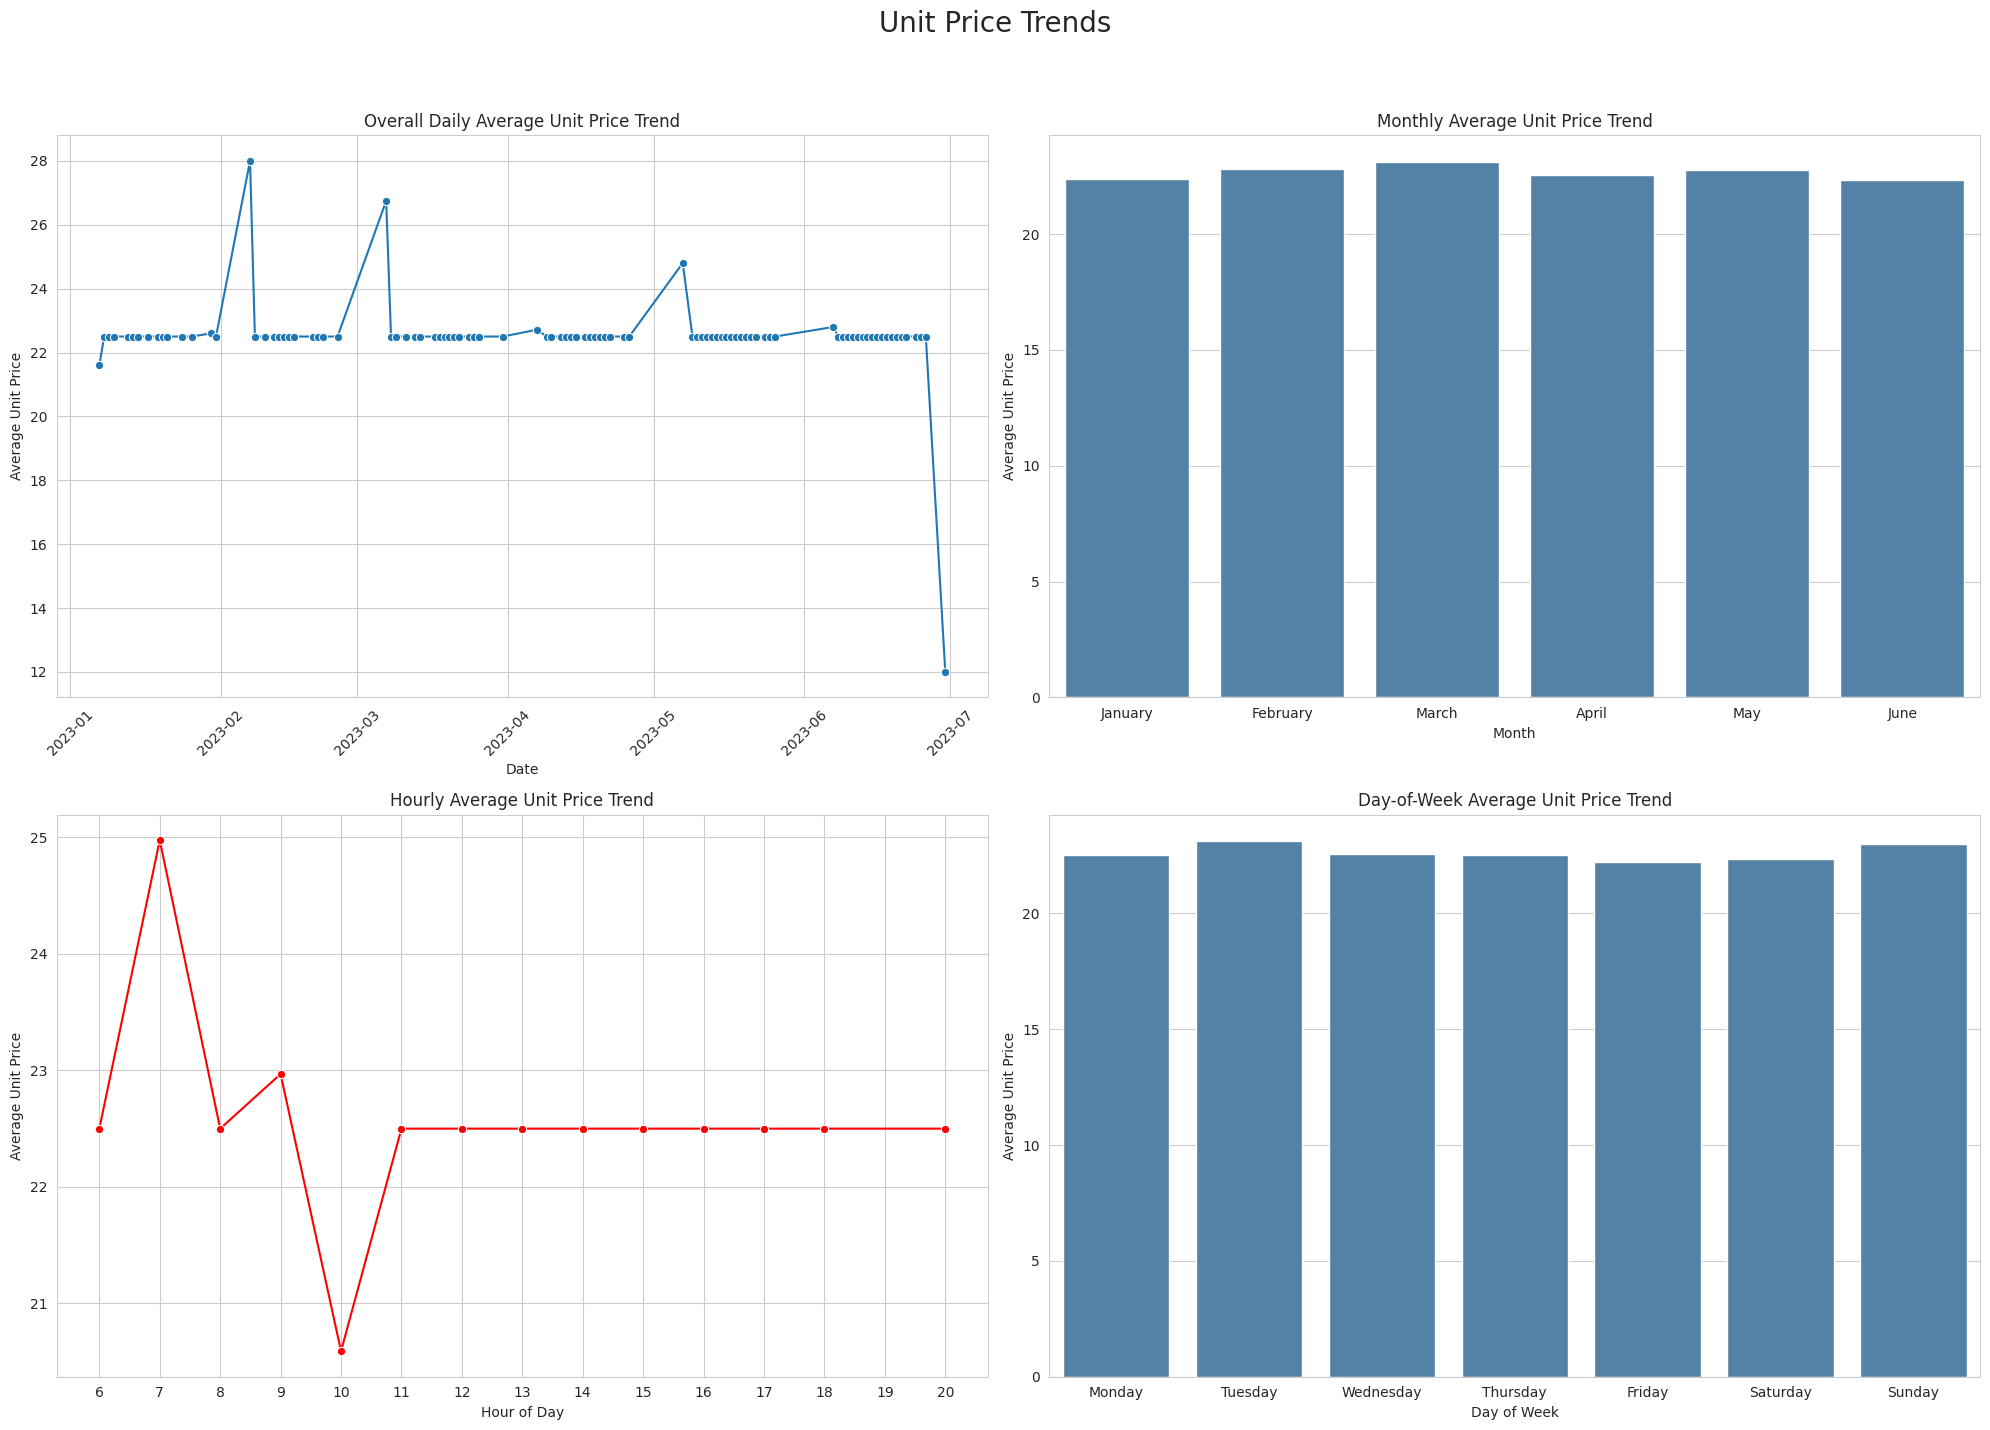

In [ ]:
# Calculate daily average unit price
product_9_bool = sales_df['product_id'] == 9
product_9 = sales_df[product_9_bool]
daily_avg_price = product_9.groupby(product_9['transaction_datetime'].dt.date)['unit_price'].mean().reset_index()
daily_avg_price.columns = ['date', 'average_unit_price']

# Calculate monthly average unit price
monthly_avg_price = product_9.groupby('month')['unit_price'].mean().reindex(['January', 'February', 'March', 'April', 'May', 'June']).reset_index()

# Calculate hourly average unit price
hourly_avg_price = product_9.groupby('hour')['unit_price'].mean().reset_index()

# Calculate day-of-week average unit price
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_of_week_avg_price = product_9.groupby('day_of_week')['unit_price'].mean().reindex(day_order).reset_index()


# Plotting
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15))
fig.suptitle('Unit Price Trends', fontsize=20)

# Plot 1: Overall Daily Average Unit Price Trend
sns.lineplot(ax=axes[0, 0], x='date', y='average_unit_price', data=daily_avg_price, marker='o')
axes[0, 0].set_title('Overall Daily Average Unit Price Trend')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Average Unit Price')
axes[0, 0].tick_params(axis='x', rotation=45)

# Plot 2: Monthly Average Unit Price Trend
sns.barplot(ax=axes[0, 1], x='month', y='unit_price', data=monthly_avg_price, color='steelblue') ## use pallete and hue
axes[0, 1].set_title('Monthly Average Unit Price Trend')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Unit Price')

# Plot 3: Hourly Average Unit Price Trend
sns.lineplot(ax=axes[1, 0], x='hour', y='unit_price', data=hourly_avg_price, marker='o', color='red')
axes[1, 0].set_title('Hourly Average Unit Price Trend')
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Average Unit Price')
axes[1, 0].set_xticks(range(hourly_avg_price['hour'].min(), hourly_avg_price['hour'].max() + 1))

# Plot 4: Day-of-Week Average Unit Price Trend
sns.barplot(ax=axes[1, 1], x='day_of_week', y='unit_price', data=day_of_week_avg_price, color='steelblue')
axes[1, 1].set_title('Day-of-Week Average Unit Price Trend')
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Average Unit Price')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Take aways
Plot 1: Overall Daily Average Unit Price Trend


```
# This is formatted as code
```


#### Conclusion
Price Dispersion Can Be Caused By
* individual discounts(coupons) as observed in lowered Price
* discount by store/day
* price increase due to Different Product size (We Can't Tell)



## Reflection Question 1

To create daily summary statistics, We first calculated the total sale amount for each transaction by multiplying `transaction_qty` by `unit_price`. After that, We grouped the data by the **date** part of `transaction_datetime` so that all transactions from the same day were combined.

### Aggregation Methods Used

- **`total_sales`: Sum**  
  We used **sum** for `total_sale_amount` because it shows the total revenue made each day.

- **`transaction_count`: Count**  
  We used **count** for `transaction_id` because it shows how many transactions happened each day.

- **`avg_transaction_value`: Mean**  
  We used **mean** for `total_sale_amount` because it shows the average value of a transaction on each day.

### Why These Choices Matter

These aggregation methods help describe daily business performance in different ways:

- **Sum** shows the overall sales made in a day.
- **Count** shows the level of transaction activity.
- **Mean** shows the typical value of each transaction.

Different aggregation choices can change the conclusion. For example, a day may have **high total sales** because of many small transactions, or because of a few large ones. Also, the **mean** can be affected by very large transactions, which may make the average look higher than normal. So, choosing different methods can lead to different interpretations of the data.

# Part 3: Bivariate Analysis

## Task 3.1: Correlation Analysis

### To Do:
1. Creating daily aggregated data (total sales, transaction count, average transaction value per
day)
2. Creating a correlation matrix for these daily metrics
3. Generating scatter plots for the strongest correlations
4. Analyze the relationship between transaction quantity and unit price

### Creating daily aggregated data (total sales, transaction count, average transaction value per day)

##### This Has been Completed While Performing Task 1.2
[Go to Daily Aggregated Metrics](#daily-aggregated-metrics)

In [ ]:
daily_metrics.head()

,transaction_datetime,total_sales,transaction_count,avg_transaction_value
0,2023-01-01,2508.20,550,4.560364
1,2023-01-02,2403.35,566,4.246201
2,2023-01-03,2565.00,582,4.407216
3,2023-01-04,2220.10,497,4.467002
4,2023-01-05,2418.85,547,4.422029


### Creating a correlation matrix for these daily metrics

In [ ]:
daily_metrics_corr = daily_metrics[['total_sales', 'transaction_count', 'avg_transaction_value']].corr()
daily_metrics_corr

,total_sales,transaction_count,avg_transaction_value
total_sales,1.000000,0.984781,0.226278
transaction_count,0.984781,1.000000,0.061557
avg_transaction_value,0.226278,0.061557,1.000000


There is a **very strong positive correlation** between `total_sales` and `transaction_count`, with a correlation coefficient of **about 0.98**.

This means that days with a higher number of transactions tend to also have higher total sales.

The scatter plot below helps visualize this strong relationship.

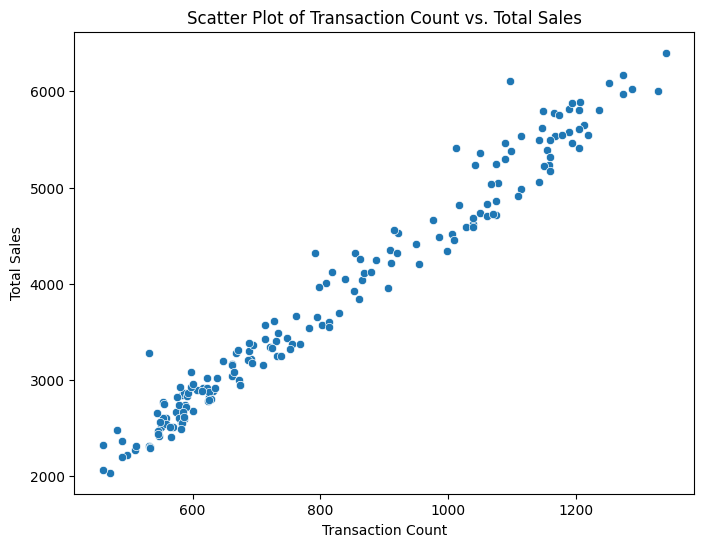

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='transaction_count', y='total_sales', data=daily_metrics)
plt.title('Scatter Plot of Transaction Count vs. Total Sales')
plt.xlabel('Transaction Count')
plt.ylabel('Total Sales')
plt.show()

### Relationship between transaction quantity and unit price

In [ ]:
## Checking Their Correlation
sales_df[['transaction_qty', 'unit_price']].corr()

,transaction_qty,unit_price
transaction_qty,1.000000,-0.123494
unit_price,-0.123494,1.000000


### Interpretation of the Correlation

The correlation between **transaction quantity (`transaction_qty`)** and **unit price (`unit_price`)** is **-0.123**.

**What this means:**

- The correlation is **negative**, meaning that as the **unit price increases, the transaction quantity tends to slightly decrease**, and vice versa.
- However, the value **-0.123 is very close to 0**, which indicates a **very weak relationship**.
- This suggests that **unit price does not strongly influence how many items are purchased per transaction**.

**Conclusion:**  
There is **little to no linear relationship** between transaction quantity and unit price.

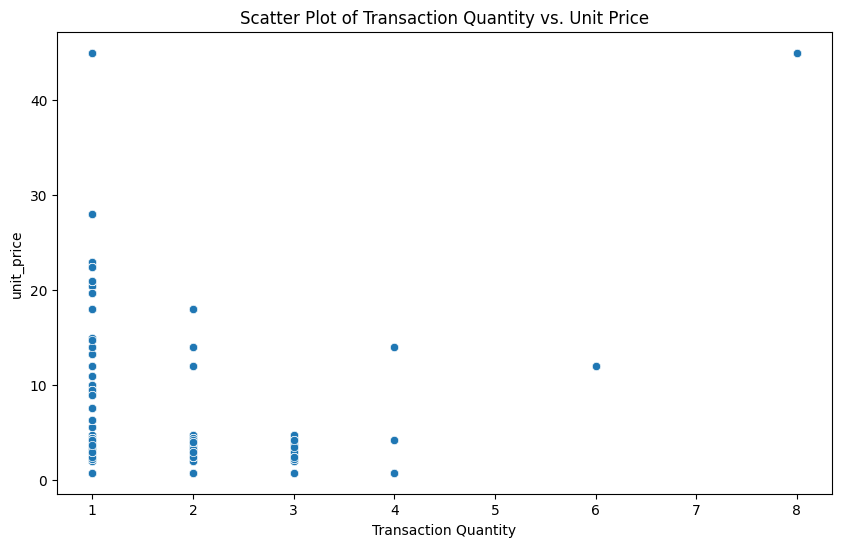

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='transaction_qty', y='unit_price', data=sales_df)
plt.title('Scatter Plot of Transaction Quantity vs. Unit Price')
plt.xlabel('Transaction Quantity')
plt.show()

### Critical Thinking Question 3 Interpretation

Negative correlation between the **average transaction value** and the **number of transactions per day** does not automatically mean that having more customers causes each customer to spend less. Correlation shows an association, but it does not prove the reason behind it.

#### **Possible Explanations**

There are several possible explanations for this relationship in Transactions:

- **Product mix:** On busy days, customers may buy more low-priced items, which increases the number of transactions but lowers the average transaction value.
- **Store differences:** Some store locations may naturally have higher traffic but lower-value purchases, while others may have fewer transactions but higher-value sales.
- **Time patterns:** Certain days of the week, months, or hours may attract more customers making quick purchases rather than larger ones.

#### Additional Analysis Needed

*Before making strategic recommendations We Compared by store location to see whether the pattern is the same across all stores.*

**Below Analysis coould Also be done on the same**.

- **Compare by product category or product type** to check whether certain products drive the relationship.
- **Analyze by day of week, month, and hour** to identify whether the pattern is linked to timing.
- **Check for outliers** to see whether a few unusually large transactions are affecting the average.

These steps would help determine whether the negative correlation reflects real customer behavior or whether it is influenced by store, product, or time-related factors.

#### Comparision By Store Location

In [ ]:
daily_store_metrics = sales_df.groupby(
    [sales_df['transaction_datetime'].dt.date, 'store_location']
).agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()

daily_store_corr = daily_store_metrics.groupby('store_location')[['transaction_count', 'avg_transaction_value']].corr().reset_index()
store_corrs = daily_store_metrics.groupby('store_location').apply(
    lambda x: x['transaction_count'].corr(x['avg_transaction_value'])
).reset_index(name='corr_transaction_vs_atv')

store_corrs

/tmp/ipykernel_267/4216404295.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  store_corrs = daily_store_metrics.groupby('store_location').apply(


,store_location,corr_transaction_vs_atv
0,Astoria,-0.016182
1,Hell's Kitchen,-0.060180
2,Lower Manhattan,0.069405


#### Conclusion

The correlation between **transaction quantity and average transaction value (ATV)** is **very close to zero for all store locations**.

- **Astoria (-0.016)** → Almost no relationship.
- **Hell's Kitchen (-0.060)** → Very weak negative relationship.
- **Lower Manhattan (0.069)** → Very weak positive relationship.

**Overall Interpretation:**

The number of items purchased in a transaction **does not significantly influence the average transaction value across the stores**.  
This suggests that other factors (such as product type, pricing strategy, or promotions) may have a stronger impact on ATV than transaction quantity.

## Task 3.2: Categorical Relationships

To analyze relationships involving categorical variables:

**Required Visualizations:**
1. Box plots comparing transaction amounts across different product categories
2. Bar chart showing total sales by day of week
3. Heatmap showing sales patterns by hour and day of week
4. Compare average transaction values across different store locations

### Box plots To compare transaction amounts across different product categories

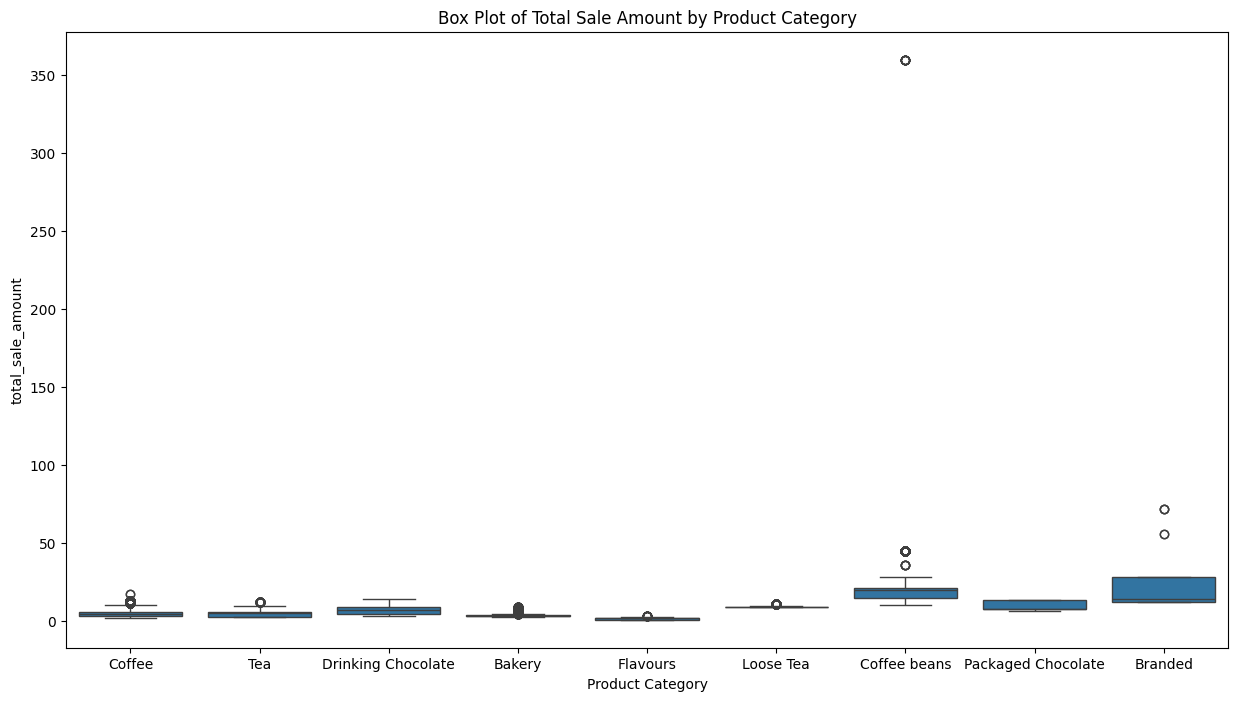

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='product_category', y='total_sale_amount', data=sales_df)
plt.title('Box Plot of Total Sale Amount by Product Category')
plt.xlabel('Product Category')
plt.show()

### Bar chart To show total sales by day of week

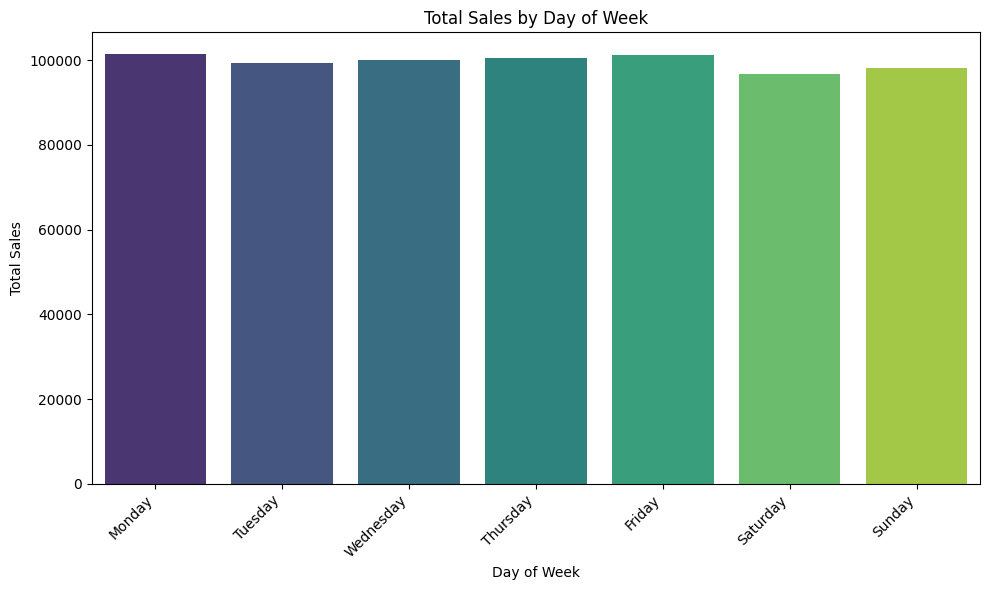

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
total_sales_by_day = sales_df.groupby('day_of_week')['total_sale_amount'].sum().reindex(day_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=total_sales_by_day.index, y=total_sales_by_day.values, palette='viridis', hue=total_sales_by_day.index, legend=False)
plt.title('Total Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Heatmap showing sales patterns by hour and day of week

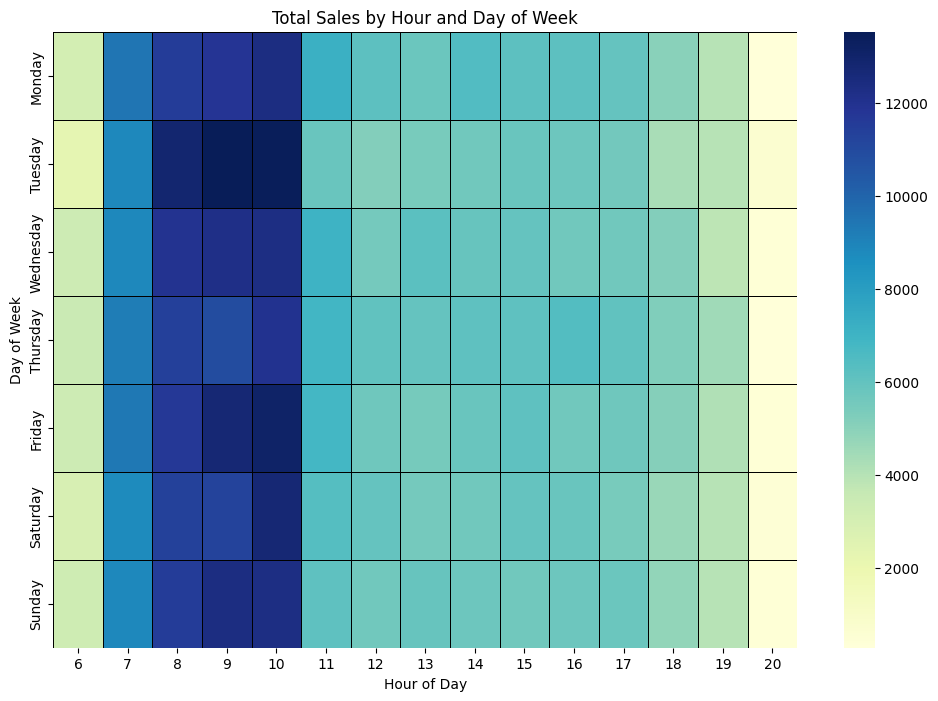

In [ ]:
sales_heatmap_data = sales_df.groupby(['day_of_week', 'hour'])['total_sale_amount'].sum().unstack()

# Ensure the days of the week are in order for plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_heatmap_data = sales_heatmap_data.reindex(day_order)

plt.figure(figsize=(12, 8))
sns.heatmap(sales_heatmap_data, cmap='YlGnBu', fmt='.0f', linewidths=.5, linecolor='black')
plt.title('Total Sales by Hour and Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

### Comparing average transaction values across different store locations

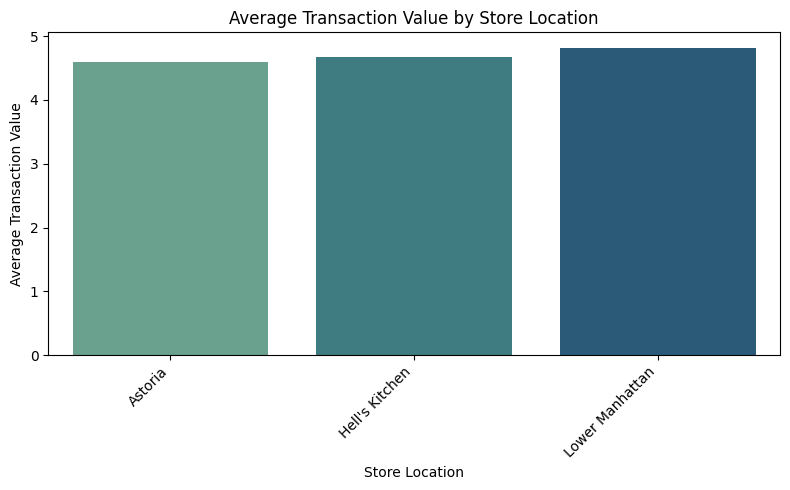

In [ ]:
store_location_atv = sales_df.groupby('store_location').agg(
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='store_location', y='avg_transaction_value', data=store_location_atv, palette='crest', hue='store_location', legend=False)
plt.xlabel('Store Location')
plt.ylabel('Average Transaction Value')
plt.title('Average Transaction Value by Store Location')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Developing and Testing Hypothisis to Explain Why Weekend Sales Might Be lower than WeekDays

#### Hypothesis 1: Customer Behavior
**Hypothesis:**  
Weekend customers make smaller purchases, resulting in a lower **average transaction value (ATV)** compared to weekdays.

In [ ]:
# Creating a copy of new Sales Dataframe for This analysis
analysis_df = sales_df.copy()

# Creating Weekend/Weekday Column
analysis_df['day_type'] = sales_df['day_of_week'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

# analysis_df.day_type.unique()

customer_behavior = analysis_df.groupby('day_type').agg(
    avg_transaction_value=('total_sale_amount', 'mean'),
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count')
).reset_index()
customer_behavior

,day_type,avg_transaction_value,total_sales,transaction_count
0,Weekday,4.687075,502520.09,107214
1,Weekend,4.694827,194854.09,41504


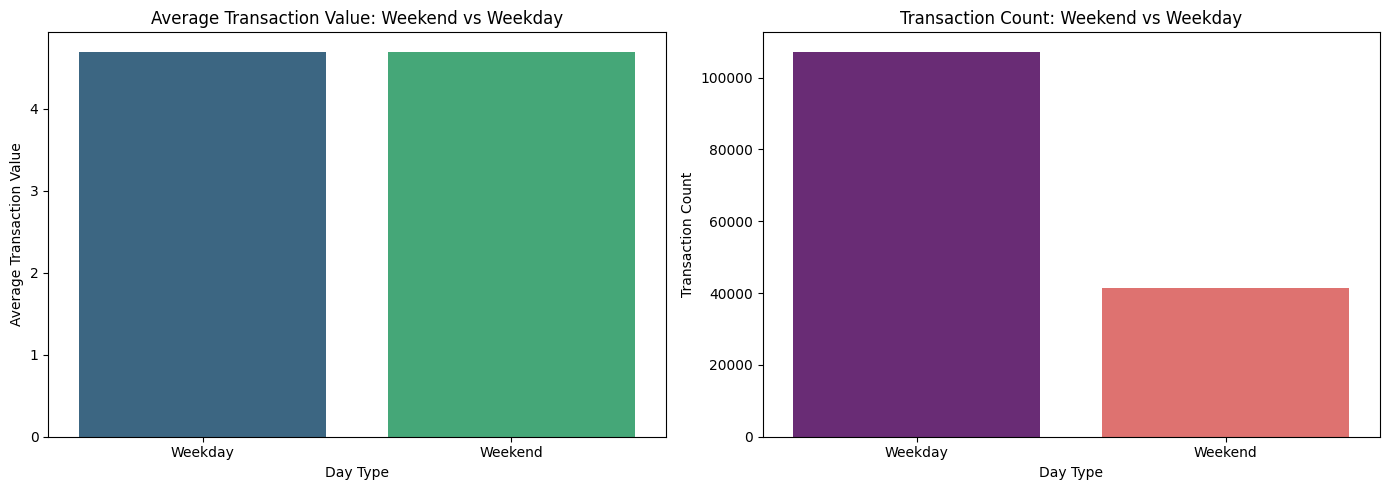

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot for Average Transaction Value
sns.barplot(x='day_type', y='avg_transaction_value', data=customer_behavior, ax=axes[0], palette='viridis', hue='day_type', legend=False)
axes[0].set_title('Average Transaction Value: Weekend vs Weekday')
axes[0].set_xlabel('Day Type')
axes[0].set_ylabel('Average Transaction Value')

# Plot for Transaction Count
sns.barplot(x='day_type', y='transaction_count', data=customer_behavior, ax=axes[1], palette='magma', hue='day_type', legend=False)
axes[1].set_title('Transaction Count: Weekend vs Weekday')
axes[1].set_xlabel('Day Type')
axes[1].set_ylabel('Transaction Count')

plt.tight_layout()
plt.show()

##### Findings
Customer analysis suggests that the lower weekend sales are not mainly caused by customers spending less per transaction.

The average transaction value (ATV) is almost the same on weekdays and weekends, which means customer spending per purchase remains fairly consistent.

This does not support the idea that weekend customers make smaller purchases.

#### Hypothesis 2: Product Mix
**Hypothesis:**  
Weekends may have a different **product mix**, with more sales coming from cheaper product categories or product types.

In [ ]:
## Checking Product Category
category_mix = analysis_df.groupby(['day_type', 'product_category']).agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_price=('unit_price', 'mean'),
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()

category_mix.sort_values(['day_type', 'total_sales'], ascending=[True, False]).head(20)

,day_type,product_category,total_sales,transaction_count,avg_price,avg_transaction_value
2,Weekday,Coffee,194349.35,42052,3.022919,4.621643
8,Weekday,Tea,141872.25,32785,2.818777,4.327352
0,Weekday,Bakery,58783.84,16274,3.550549,3.612132
4,Weekday,Drinking Chocolate,52188.50,8252,4.149085,6.324346
3,Weekday,Coffee beans,28540.15,1253,20.974581,22.777454
1,Weekday,Branded,9566.00,527,17.586338,18.151803
6,Weekday,Loose Tea,8093.15,873,9.270504,9.270504
5,Weekday,Flavours,6006.40,4853,0.800000,1.237667
7,Weekday,Packaged Chocolate,3120.45,345,9.044783,9.044783
11,Weekend,Coffee,75241.45,16254,3.023739,4.629104


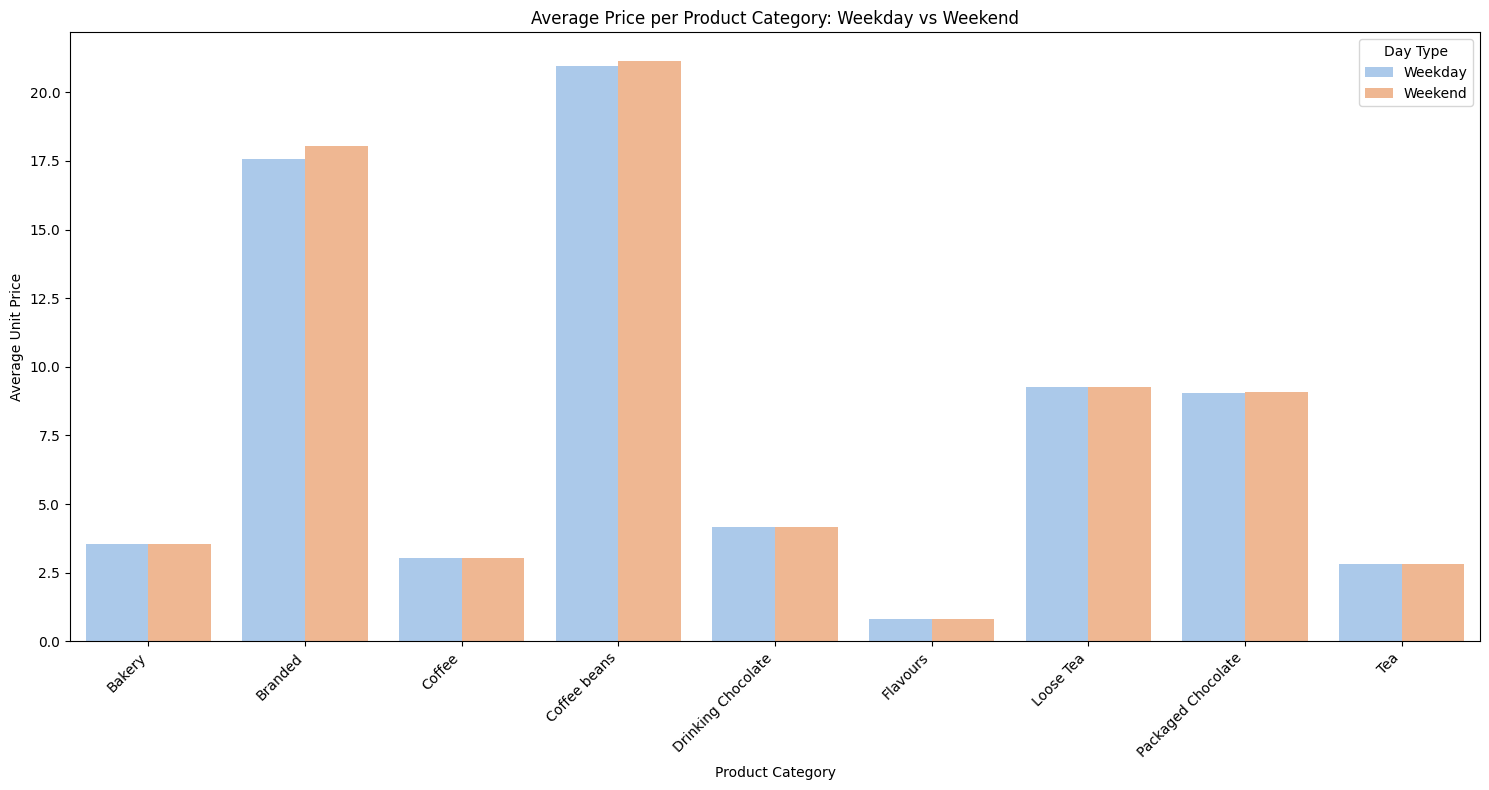

In [ ]:
## Visualizing Average Price per Product Category: Weekday vs Weekend
plt.figure(figsize=(15, 8))
sns.barplot(x='product_category', y='avg_price', hue='day_type', data=category_mix, palette='pastel')
plt.title('Average Price per Product Category: Weekday vs Weekend')
plt.xlabel('Product Category')
plt.ylabel('Average Unit Price')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

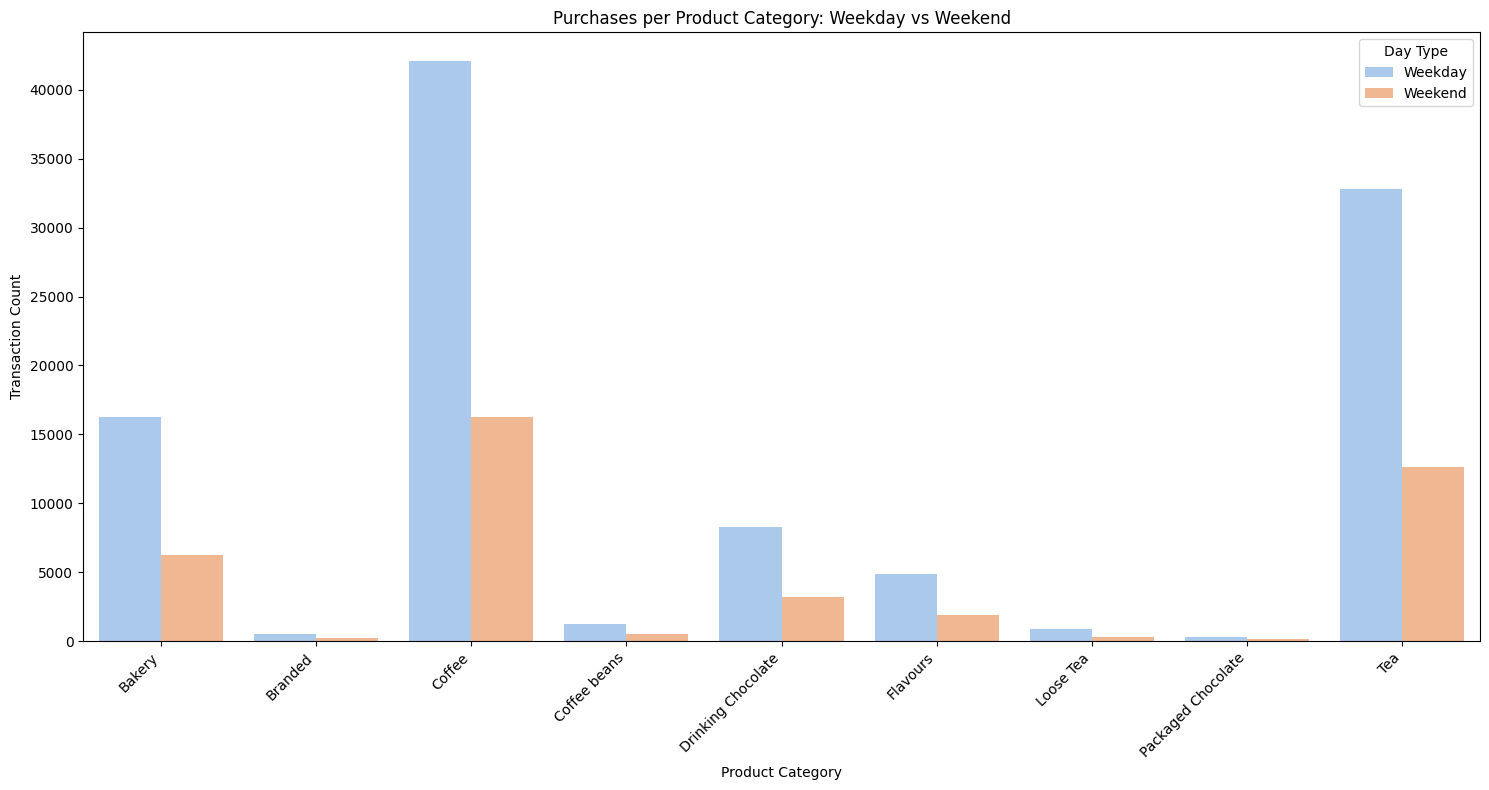

In [ ]:
## Visualizing Purchases per Product Category: Weekday vs Weekend
plt.figure(figsize=(15, 8))
sns.barplot(x='product_category', y='transaction_count', hue='day_type', data=category_mix, palette='pastel')
plt.title('Purchases per Product Category: Weekday vs Weekend')
plt.xlabel('Product Category')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

##### Findings
From Product Mix Analysis, We See that, Although the average prices across product categories are similar on weekdays and weekends,

key categories such as `Coffee`, `Bakery`, and `Tea` have noticeably higher transaction counts on weekdays.

This means that weekday sales are stronger because these popular categories are purchased more often during the week.

#### Hypothesis 3: Location characteristics
**Hypothesis:**  
Some **store locations perform significantly worse on weekends**, which lowers total weekend sales.

In [ ]:
location_analysis = analysis_df.groupby(['day_type', 'store_location']).agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()

location_analysis.sort_values(['store_location', 'day_type'])

,day_type,store_location,total_sales,transaction_count,avg_transaction_value
0,Weekday,Astoria,167179.90,36467,4.584416
3,Weekend,Astoria,64532.41,13985,4.614402
1,Weekday,Hell's Kitchen,169878.01,36444,4.661344
4,Weekend,Hell's Kitchen,66151.11,14152,4.674329
2,Weekday,Lower Manhattan,165462.18,34303,4.823548
5,Weekend,Lower Manhattan,64170.57,13367,4.800671


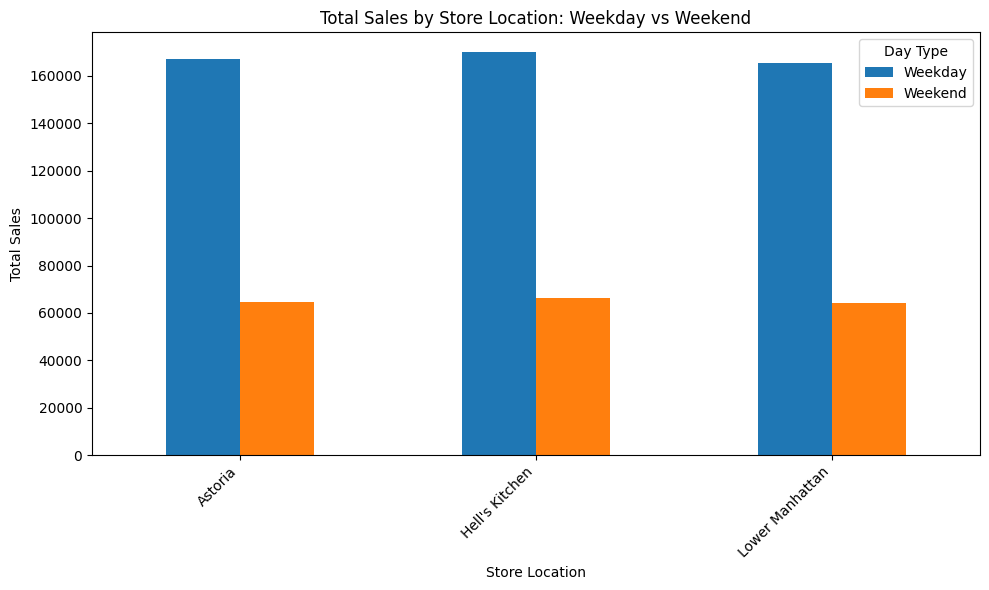

In [ ]:
location_pivot = location_analysis.pivot(
    index='store_location',
    columns='day_type',
    values='total_sales'
)

# Plotting the data
location_pivot.plot(kind='bar', figsize=(10, 6))
plt.title('Total Sales by Store Location: Weekday vs Weekend')
plt.xlabel('Store Location')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

##### Findings
store location analysis shows that all store locations experienced a similar drop in sales on weekends. This suggests that the weekend decline is not being caused by one weak store,

#### Hypothesis 4: Timing Patterns

**Hypothesis:**  
Weekend hourly sales patterns may be shorter or weaker compared to weekday peak hours.

In [ ]:
hourly_analysis = analysis_df.groupby(['day_type', 'hour']).agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()

hourly_analysis.head()

,day_type,hour,total_sales,transaction_count,avg_transaction_value
0,Weekday,6,15628.19,3276,4.770510
1,Weekday,7,45741.36,9629,4.750375
2,Weekday,8,59488.17,12677,4.692606
3,Weekday,9,61205.28,12786,4.786898
4,Weekday,10,63276.16,13310,4.754032


In [ ]:
hourly_sales_pivot = hourly_analysis.pivot(
    index='hour',
    columns='day_type',
    values='total_sales'
)

hourly_sales_pivot

day_type,Weekday,Weekend
hour,,
6,15628.19,6223.33
7,45741.36,17607.76
8,59488.17,22895.65
9,61205.28,23634.15
10,63276.16,25026.23
11,33788.49,12477.15
12,28579.20,11570.64
13,28909.82,11457.63
14,29904.33,11390.06


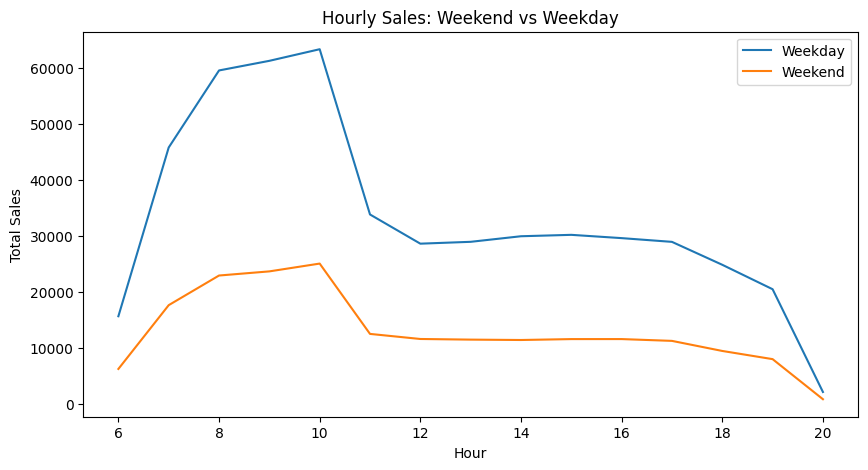

In [ ]:
weekday_hourly = hourly_analysis[hourly_analysis['day_type'] == 'Weekday']
weekend_hourly = hourly_analysis[hourly_analysis['day_type'] == 'Weekend']

plt.figure(figsize=(10,5))
plt.plot(weekday_hourly['hour'], weekday_hourly['total_sales'], label='Weekday')
plt.plot(weekend_hourly['hour'], weekend_hourly['total_sales'], label='Weekend')
plt.xlabel('Hour')
plt.ylabel('Total Sales')
plt.title('Hourly Sales: Weekend vs Weekday')
plt.legend()
plt.show()

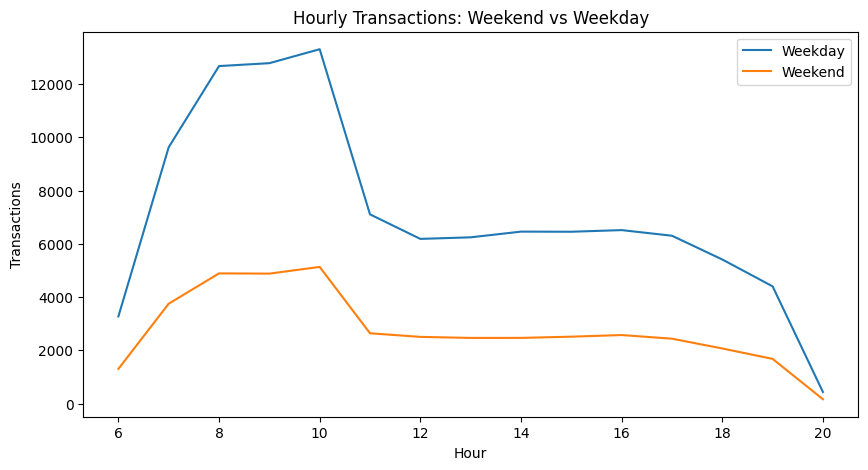

In [ ]:
weekday_hourly = hourly_analysis[hourly_analysis['day_type'] == 'Weekday']
weekend_hourly = hourly_analysis[hourly_analysis['day_type'] == 'Weekend']

plt.figure(figsize=(10,5))
plt.plot(weekday_hourly['hour'], weekday_hourly['transaction_count'], label='Weekday')
plt.plot(weekend_hourly['hour'], weekend_hourly['transaction_count'], label='Weekend')
plt.xlabel('Hour')
plt.ylabel('Transactions')
plt.title('Hourly Transactions: Weekend vs Weekday')
plt.legend()
plt.show()

In [ ]:
overall_daytype = analysis_df.groupby('day_type').agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    avg_transaction_value=('total_sale_amount', 'mean')
).reset_index()

overall_daytype

,day_type,total_sales,transaction_count,avg_transaction_value
0,Weekday,502520.09,107214,4.687075
1,Weekend,194854.09,41504,4.694827


##### Findings
hourly analysis shows that weekend hourly sales patterns are similar, which suggests that timing is also not a strong explanation for the lower weekend sales.

#### Conclusion
The results instead suggest that the main reason for lower weekend sales is **`lower transaction volume`**. Although the average prices across product categories are similar on weekdays and weekends,

key categories such as **`Coffee`, `Bakery`, and `Tea`** have noticeably higher transaction counts on weekdays. This means that weekday sales are stronger because these popular categories are purchased more often during the week.

Results shows That any strategies to boost weekend sales should focus on increasing transaction count, rather than altering product pricing, mix, or specific store
operations based on perceived differences in customer behavior.

# Part 4: Advanced Pattern Recognition

## Task 4.1: Time Series Patterns
To Analyze temporal patterns in the data:

To Do:
1. Create daily sales totals and plot them over time to identify trends
2. Examine monthly patterns across the 6-month period
3. Analyze hourly patterns to identify peak business hours
4. Investigate any weekly patterns in customer behavior

### Creating daily sales totals and plot them over time to identify trends

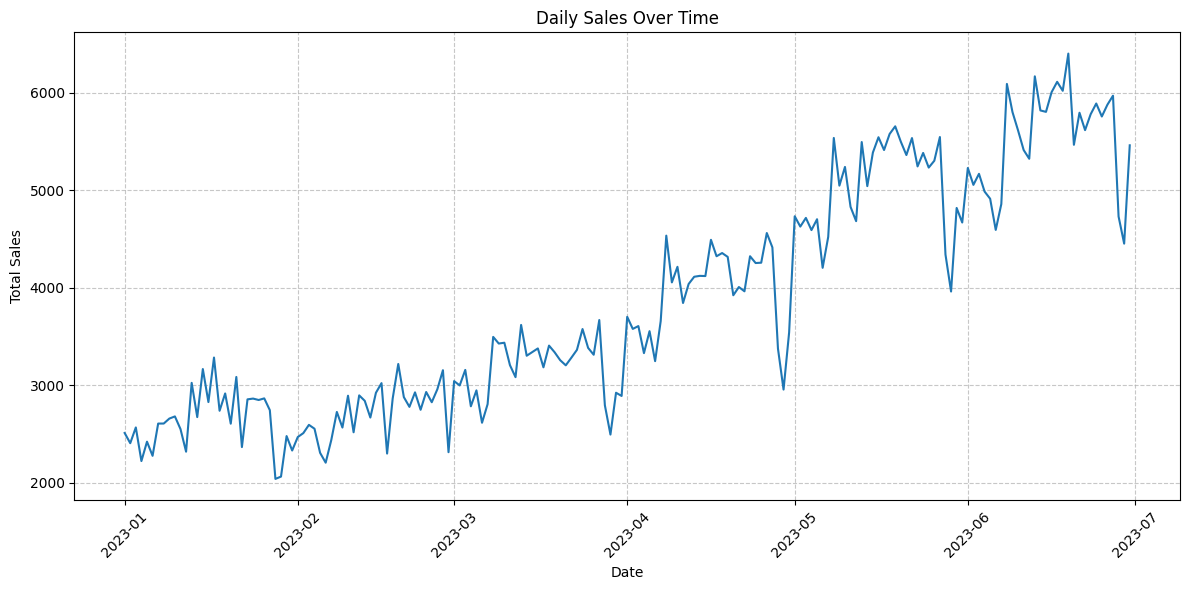

In [ ]:
# Using daily_metrics Dataset

plt.figure(figsize=(12, 6))

sns.lineplot(x='transaction_datetime', y='total_sales', data=daily_metrics)

plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Daily Sales Over Time')

plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() ### it shows Overall Increasing Sales Trend Overtime

In [ ]:
daily_metrics.head()

,transaction_datetime,total_sales,transaction_count,avg_transaction_value
0,2023-01-01,2508.20,550,4.560364
1,2023-01-02,2403.35,566,4.246201
2,2023-01-03,2565.00,582,4.407216
3,2023-01-04,2220.10,497,4.467002
4,2023-01-05,2418.85,547,4.422029


### Examining monthly patterns across the 6-month period

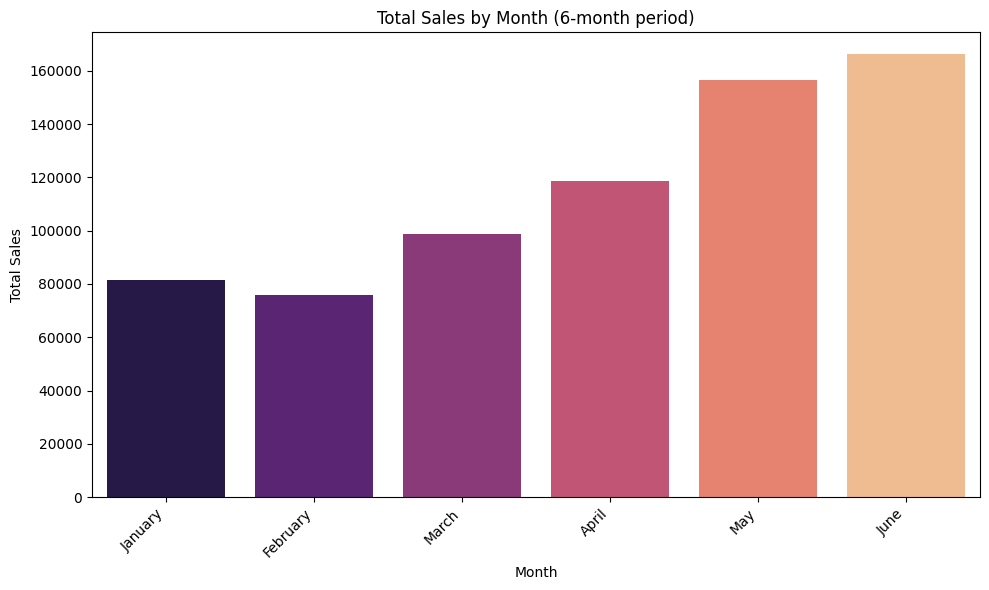

In [ ]:
## Creating Monthly Sales
monthly_sales = sales_df.groupby('month')['total_sale_amount'].sum().reset_index()

# Define the correct order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June']
monthly_sales['month'] = pd.Categorical(monthly_sales['month'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('month')

## Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='month', y='total_sale_amount', data=monthly_sales, palette='magma', hue='month', legend=False)
plt.title('Total Sales by Month (6-month period)')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show() ### We See Sales are increasing except for Feb (few Days (28 Days))

### Analyzing hourly patterns to identify peak business hours

---



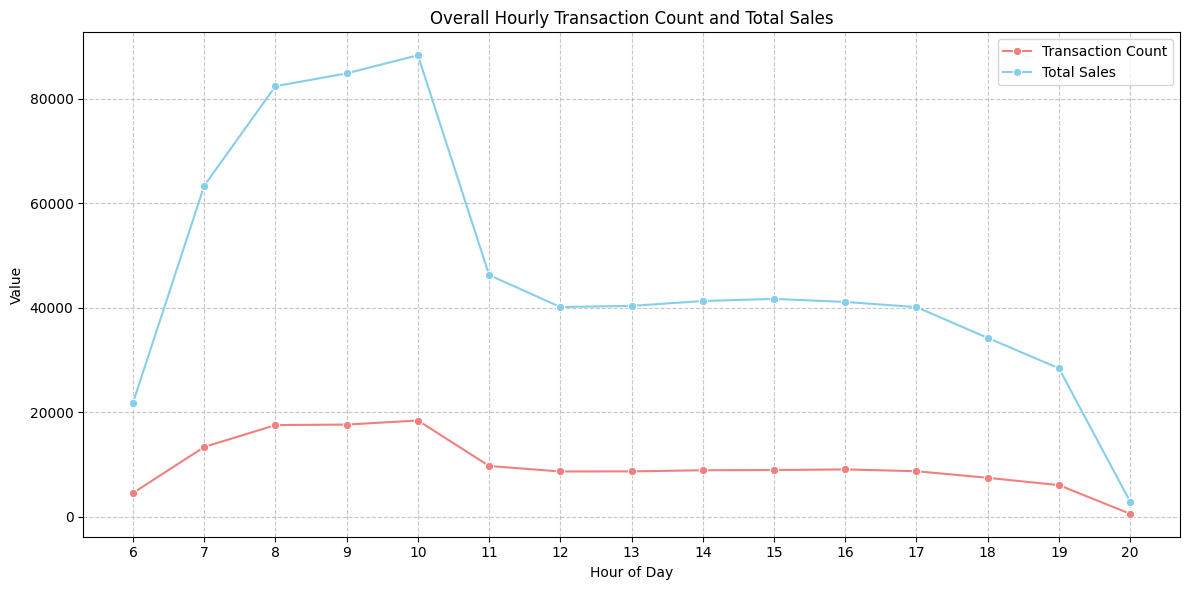

In [ ]:
# Group by hour to get overall hourly patterns
hourly_patterns = sales_df.groupby('hour').agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    average_sale_per_transaction=('total_sale_amount', 'mean')
).reset_index()

# Plotting hourly transaction count and total sales on the same plot
plt.figure(figsize=(12, 6))

sns.lineplot(x='hour', y='transaction_count', data=hourly_patterns, marker='o', color='lightcoral', label='Transaction Count')
sns.lineplot(x='hour', y='total_sales', data=hourly_patterns, marker='o', color='skyblue', label='Total Sales')

plt.title('Overall Hourly Transaction Count and Total Sales')
plt.xlabel('Hour of Day')
plt.ylabel('Value')

plt.xticks(range(hourly_patterns['hour'].min(), hourly_patterns['hour'].max() + 1))

plt.legend()

plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show() ## It shows Peak Hours 6 - 11 Morning

### Investigating any weekly patterns in customer behavior

Weekly Patterns in Customer Behavior:
  day_of_week  total_sales  transaction_count  average_sale_per_transaction
0      Monday    101478.73              21588                      4.700701
1     Tuesday     99243.44              21144                      4.693693
2   Wednesday    100101.54              21251                      4.710439
3    Thursday    100525.43              21588                      4.656542
4      Friday    101170.95              21643                      4.674534
5    Saturday     96698.98              20455                      4.727401
6      Sunday     98155.11              21049                      4.663172


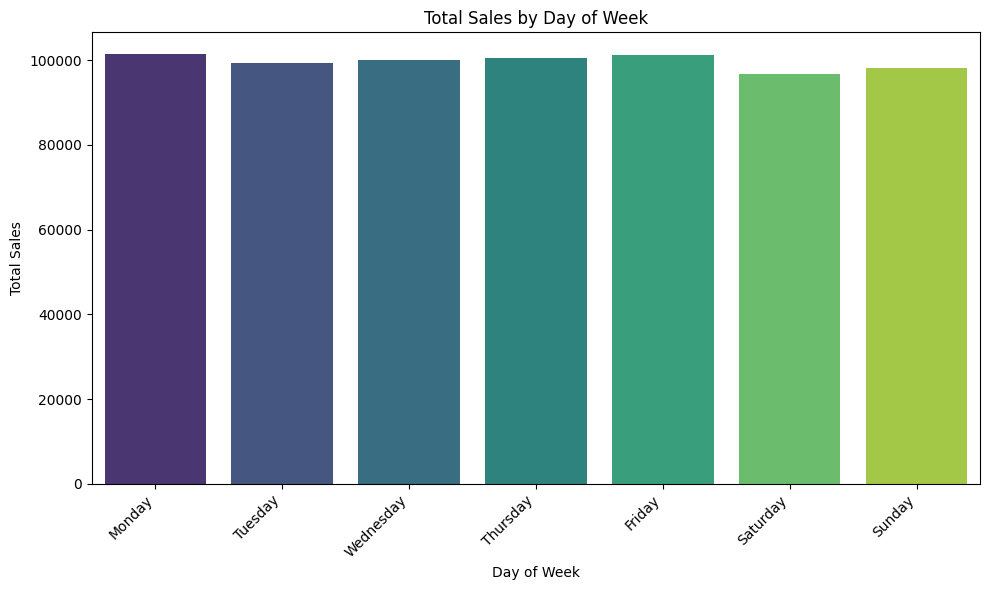

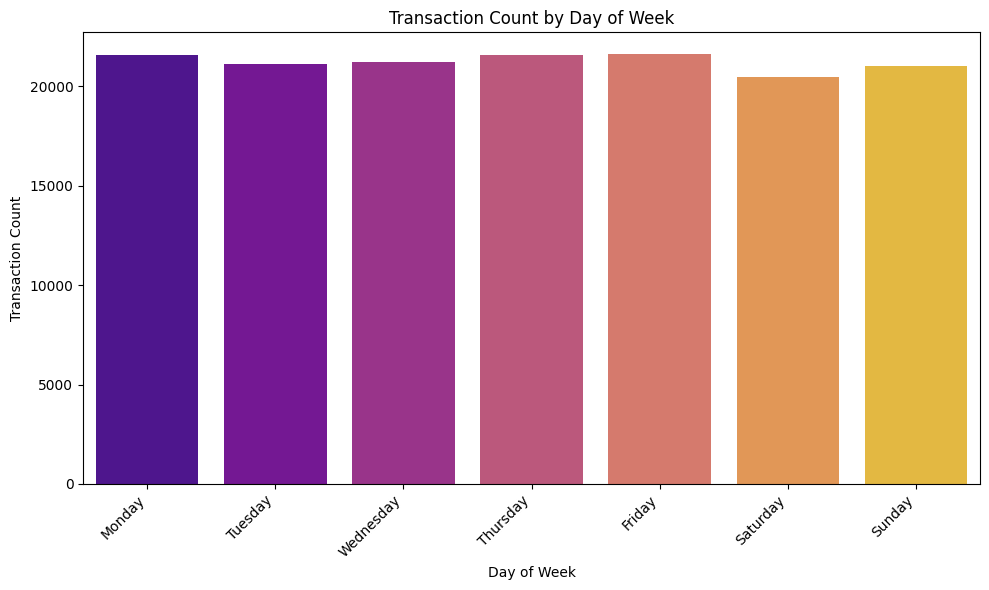

In [ ]:
weekly_patterns = sales_df.groupby('day_of_week').agg(
    total_sales=('total_sale_amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    average_sale_per_transaction=('total_sale_amount', 'mean')
).reindex(day_order).reset_index()

print("Weekly Patterns in Customer Behavior:")
print(weekly_patterns)

# Plotting weekly total sales
plt.figure(figsize=(10, 6))
sns.barplot(x='day_of_week', y='total_sales', data=weekly_patterns, palette='viridis', hue='day_of_week', legend=False)
plt.title('Total Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()  ## Dip in weekend (sales & txn count) but average_sale_per_transaction is constant

# Plotting weekly transaction count
plt.figure(figsize=(10, 6))
sns.barplot(x='day_of_week', y='transaction_count', data=weekly_patterns, palette='plasma', hue='day_of_week', legend=False)
plt.title('Transaction Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Transaction Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show() ## Dip in weekend (sales & txn count) but average_sale_per_transaction is constant

### Critical Thinking Question 4

#### Investigating the Sales Decline
The steady drop in sales from January to June could signal either a **real business issue** or simply **seasonal variation**.  
To clarify, I’d start by breaking down the data:

- **Trend analysis**: Compare monthly totals, transaction counts, and average spend per customer.  
- **Store-level view**: Check if the decline is widespread or concentrated in specific locations.  
- **Category-level view**: Identify whether certain product lines are driving the drop.  
- **Time-of-day consistency**: Validate if weekday peaks (10 AM, 2 PM) shift on weekends, and whether this aligns with customer behavior.

If the decline is consistent across metrics and locations, it points to a broader demand issue. If isolated, it may be operational or product-specific.

---

#### External Factors to Research
To understand the “why,” We’d look outward:

- **Seasonality**: Weather shifts (e.g., hot drinks vs. cold drinks demand).  
- **Tourism & foot traffic**: Changes in visitor flows or local commuting patterns.  
- **Economic signals**: Inflation, disposable income, or local employment trends.  
- **Competition**: New entrants or aggressive promotions by rivals.  
- **Events & schedules**: School calendars, holidays, or community events affecting buying habits.

---

#### Additional Data Needed
To separate **temporary dips** from **structural declines**, We’d gather:

- **Historical sales**: Multi-year data to spot recurring seasonal patterns.  
- **Marketing activity**: Campaigns, promotions, or loyalty programs that may have tapered off.  
- **Weather & tourism stats**: Correlate external conditions with sales behavior.  
- **Local economic indicators**: Consumer confidence, spending power, or policy changes.  

With this layered view, We can distinguish between a **normal seasonal cycle** and a **long-term downward trend** that requires intervention.


## Task 4.2: Product and Location Performance Analysis

To Compare performance across different dimensions

Sub Tasks:
1. Calculate key performance metrics by store location (total sales, average transaction
value, transaction count)
2. Identify top and bottom performing product categories
3. Analyze which products are most popular at different times of day
4. Compare product mix across different store locations

### Calculating key performance metrics by store location (total sales, average transaction value, transaction count)

In [ ]:
store_metrics = sales_df.groupby('store_location').agg(
    total_sales=('total_sale_amount', 'sum'),
    avg_transaction_value=('total_sale_amount', 'mean'),
    transaction_count=('transaction_id', 'count')
).reset_index()

print("Key Performance Metrics by Store Location:")
print(store_metrics)

Key Performance Metrics by Store Location:
    store_location  total_sales  avg_transaction_value  transaction_count
0          Astoria    231712.31               4.592728              50452
1   Hell's Kitchen    236029.12               4.664976              50596
2  Lower Manhattan    229632.75               4.817133              47670


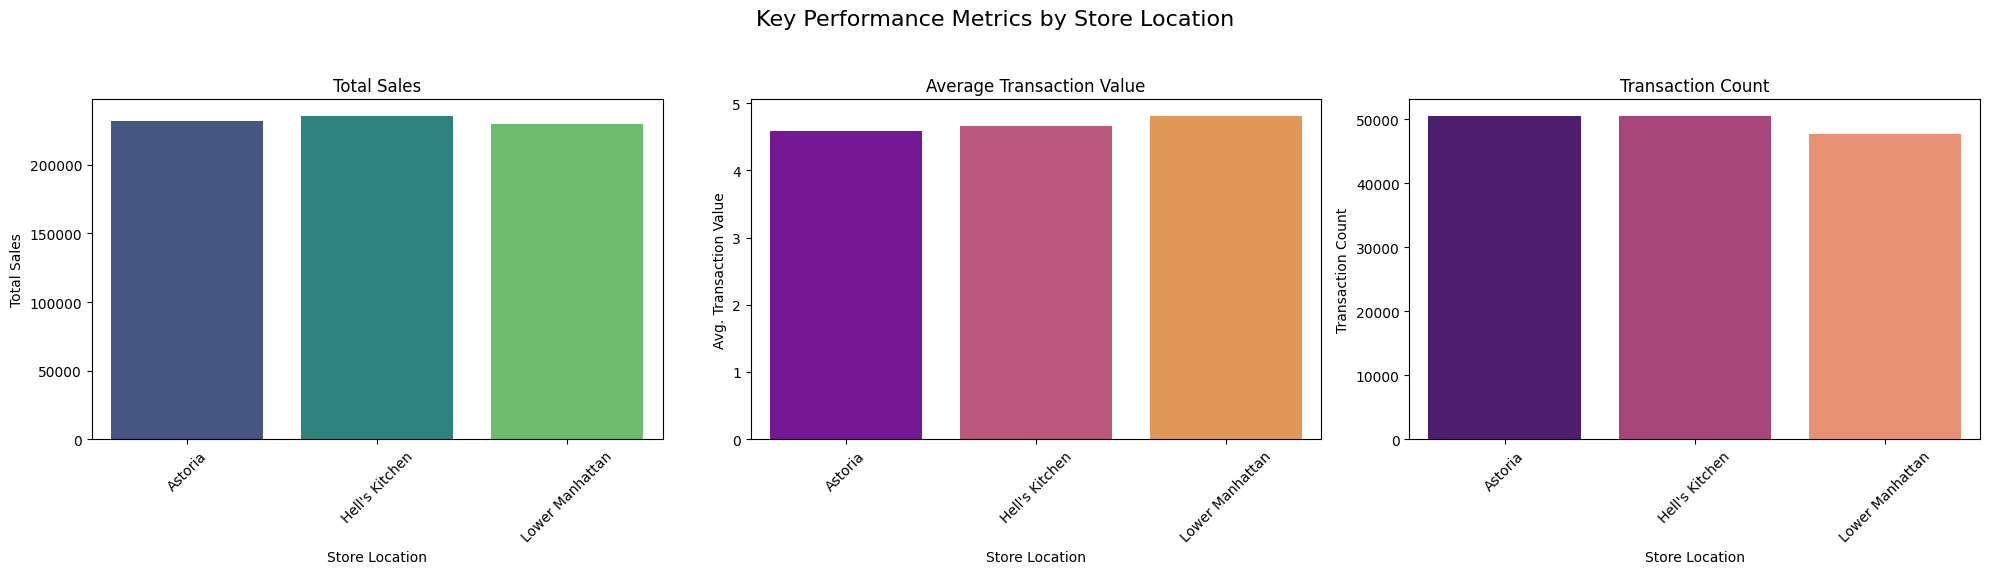

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Key Performance Metrics by Store Location', fontsize=16)

# Plot Total Sales
sns.barplot(x='store_location', y='total_sales', data=store_metrics, ax=axes[0], palette='viridis', hue='store_location', legend=False)
axes[0].set_title('Total Sales')
axes[0].set_xlabel('Store Location')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=45)

# Plot Average Transaction Value
sns.barplot(x='store_location', y='avg_transaction_value', data=store_metrics, ax=axes[1], palette='plasma', hue='store_location', legend=False)
axes[1].set_title('Average Transaction Value')
axes[1].set_xlabel('Store Location')
axes[1].set_ylabel('Avg. Transaction Value')
axes[1].tick_params(axis='x', rotation=45)

# Plot Transaction Count
sns.barplot(x='store_location', y='transaction_count', data=store_metrics, ax=axes[2], palette='magma', hue='store_location', legend=False)
axes[2].set_title('Transaction Count')
axes[2].set_xlabel('Store Location')
axes[2].set_ylabel('Transaction Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Identifying top and bottom performing product categories (By Sales)

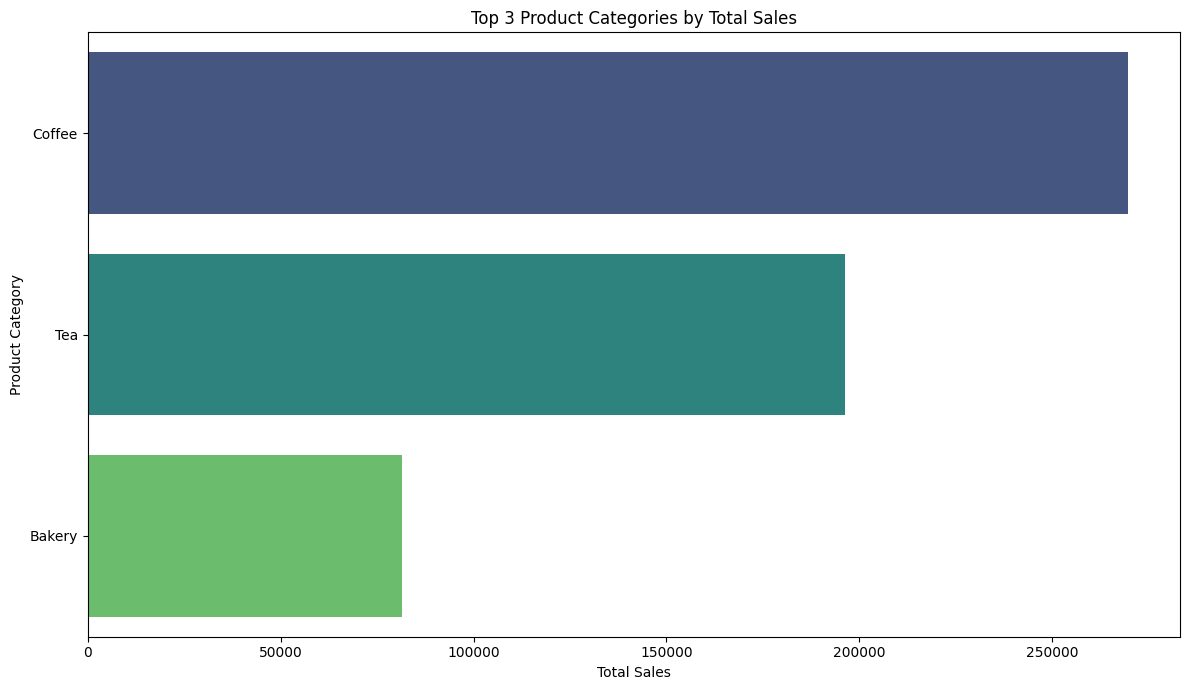

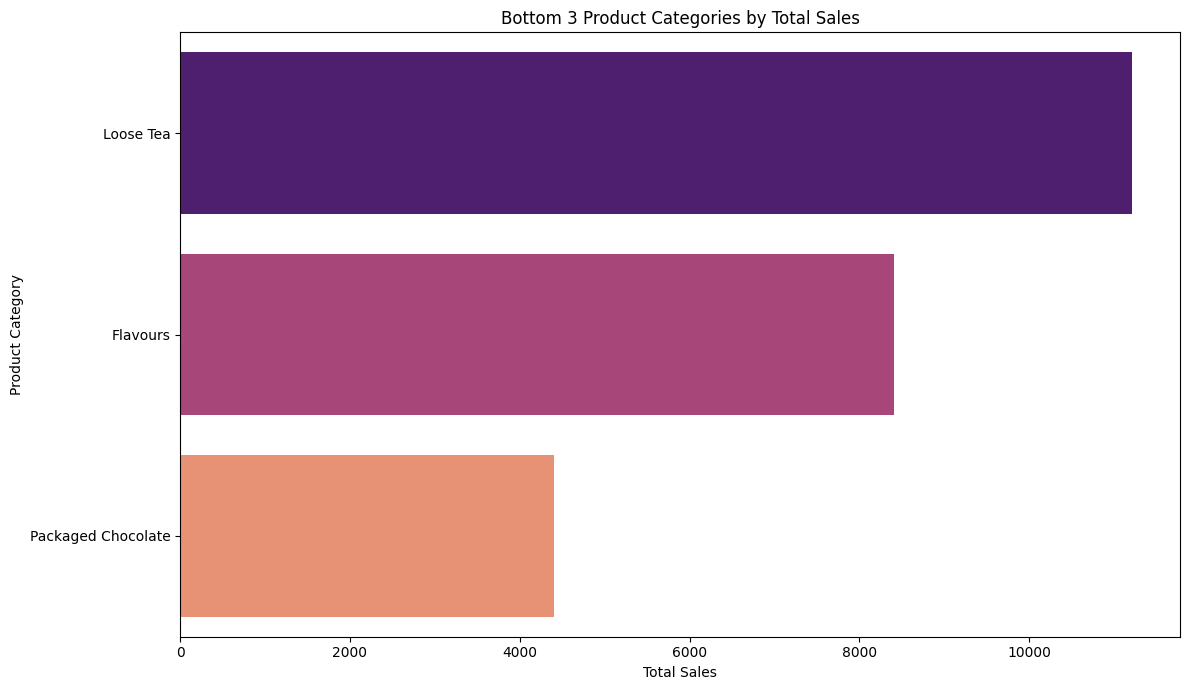

In [ ]:
category_sales = sales_df.groupby('product_category')['total_sale_amount'].sum().reset_index()
category_sales_sorted = category_sales.sort_values(by='total_sale_amount', ascending=False)

# print("Top 3 Product Categories by Total Sales:")
# print(category_sales_sorted.head(3))

# print("\nBottom 3 Product Categories by Total Sales:")
# print(category_sales_sorted.tail(3))

# Visualize Top 3
plt.figure(figsize=(12, 7))
sns.barplot(x='total_sale_amount', y='product_category', data=category_sales_sorted.head(3), palette='viridis', hue='product_category', legend=False)
plt.title('Top 3 Product Categories by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

# Visualize Bottom 3
plt.figure(figsize=(12, 7))
sns.barplot(x='total_sale_amount', y='product_category', data=category_sales_sorted.tail(3), palette='magma', hue='product_category', legend=False)
plt.title('Bottom 3 Product Categories by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

### Identifying top and bottom performing product categories (By Volume)

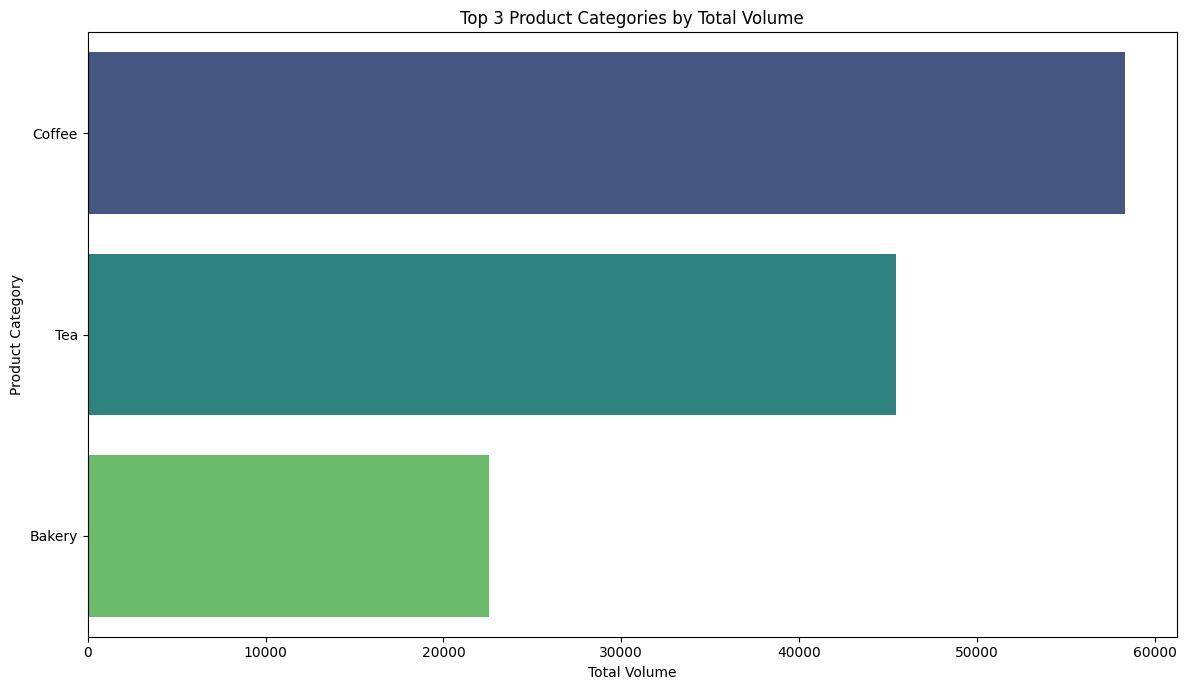

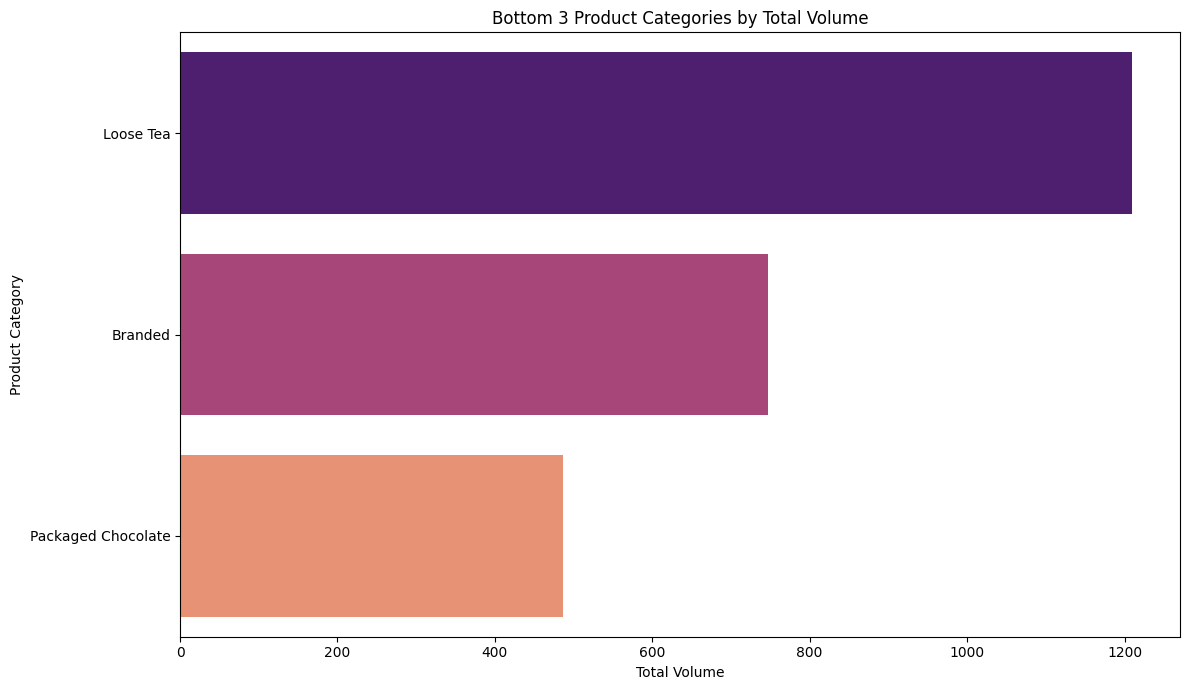

In [ ]:
category_sales = sales_df.groupby('product_category')['transaction_id'].count().reset_index()
category_sales_sorted = category_sales.sort_values(by='transaction_id', ascending=False)

# print("Top 3 Product Categories by Total Volume:")
# print(category_sales_sorted.head(3))

# print("\nBottom 3 Product Categories by Total Volume:")
# print(category_sales_sorted.tail(3))

# Visualize Top 3
plt.figure(figsize=(12, 7))
sns.barplot(x='transaction_id', y='product_category', data=category_sales_sorted.head(3), palette='viridis', hue='product_category', legend=False)
plt.title('Top 3 Product Categories by Total Volume')
plt.xlabel('Total Volume')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

# Visualize Bottom 3
plt.figure(figsize=(12, 7))
sns.barplot(x='transaction_id', y='product_category', data=category_sales_sorted.tail(3), palette='magma', hue='product_category', legend=False)
plt.title('Bottom 3 Product Categories by Total Volume')
plt.xlabel('Total Volume')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

### Analyzing which products are most popular at different times of day

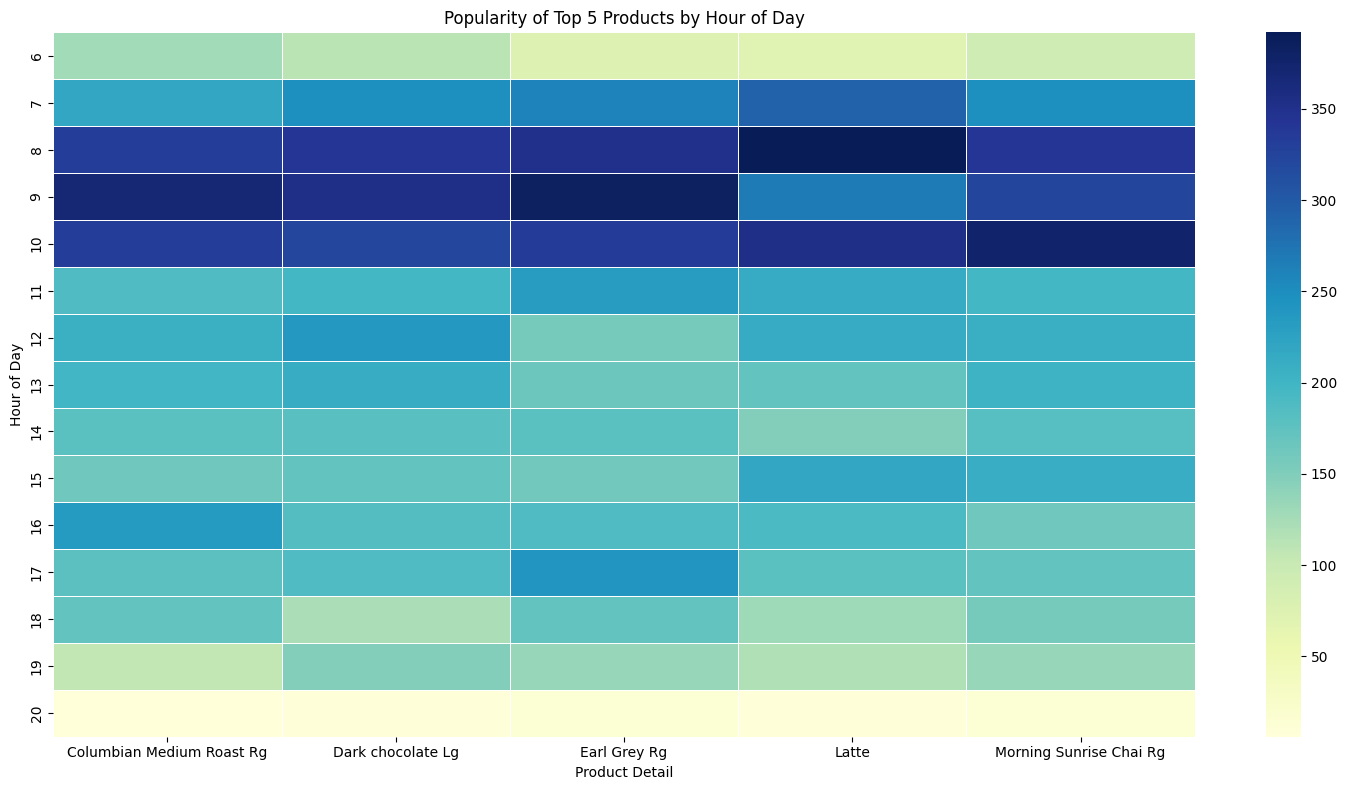

In [ ]:
hourly_product_popularity = sales_df.groupby(['hour', 'product_detail']).agg(
    popularity=('transaction_id', 'count')
).reset_index()

# Find the top 5 most popular products overall to focus the analysis
top_5_overall_products = sales_df['product_detail'].value_counts().head(5).index.tolist()

# Filter the hourly popularity data to include only the top 5 overall products
hourly_top_product_popularity = hourly_product_popularity[
    hourly_product_popularity['product_detail'].isin(top_5_overall_products)
]

# Pivot the table for heatmap visualization
popularity_heatmap_data = hourly_top_product_popularity.pivot_table(
    index='hour', columns='product_detail', values='popularity', fill_value=0
)

# Plotting the heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(popularity_heatmap_data, cmap='YlGnBu', fmt='g', linewidths=.5)
plt.title('Popularity of Top 5 Products by Hour of Day')
plt.xlabel('Product Detail')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()

In [ ]:
hourly_product_popularity = sales_df.groupby(['hour', 'product_category']).agg(
    transaction_count=('transaction_id', 'count')
).reset_index()

hourly_product_popularity.head()

,hour,product_category,transaction_count
0,6,Bakery,728
1,6,Branded,25
2,6,Coffee,1629
3,6,Coffee beans,50
4,6,Drinking Chocolate,378


In [ ]:
top_hourly_products = hourly_product_popularity.loc[
    hourly_product_popularity.groupby('hour')['transaction_count'].idxmax()
]

top_hourly_products

,hour,product_category,transaction_count
2,6,Coffee,1629
11,7,Coffee,4983
20,8,Coffee,6669
29,9,Coffee,6626
38,10,Coffee,6994
47,11,Coffee,3966
56,12,Coffee,3540
65,13,Coffee,3614
74,14,Coffee,3589
83,15,Coffee,3629


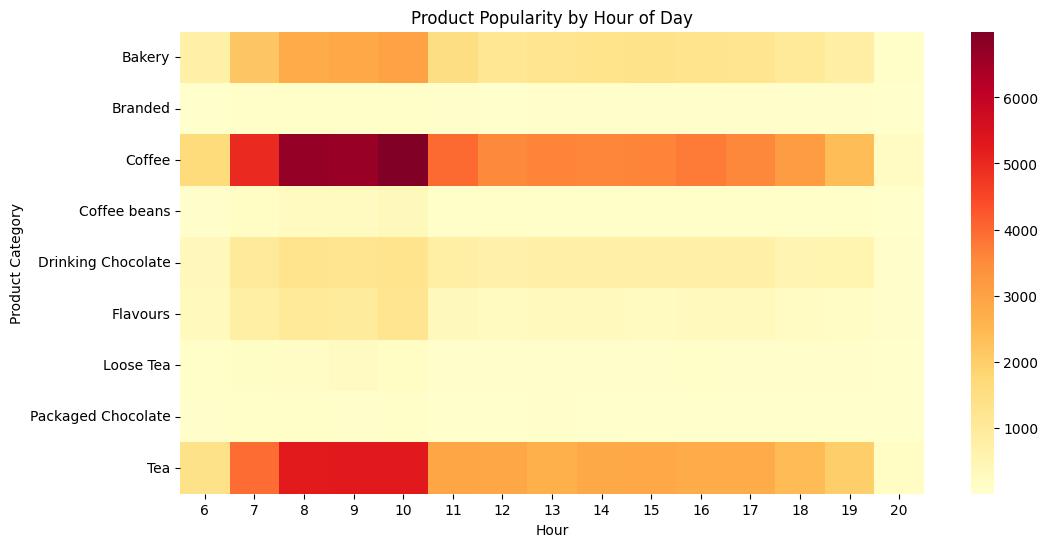

In [ ]:
heatmap_data = sales_df.pivot_table(
    values='transaction_id',
    index='product_category',
    columns='hour',
    aggfunc='count'
)

plt.figure(figsize=(12,6))

sns.heatmap(heatmap_data, cmap='YlOrRd')

plt.title('Product Popularity by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Product Category')

plt.show()

### Compare product mix across different store locations